# Feature Selection & Data Preparation Pipeline
## Churn Risk Prediction — Production-Ready Notebook (Part 2A)

**Role:** Senior AI Engineer, Senior Machine Learning Engineer

**Objective:** Select the most informative, business-meaningful, leakage-free features
from the Part 1 engineered dataset, then train, evaluate, tune, and explain a churn-risk
classification model — culminating in a production-ready model and pipeline artifact
set for Part 3's deployment stage.

**Input:** `engineered_dataset.csv` (Part 1's output, 20,000 rows x 120 columns).

**Scope notes made explicit up front** (so every later step's runtime/design choice is
traceable back to a stated reason, not a silent shortcut):
- Hyperparameter search uses a **bounded iteration budget** (`RandomizedSearchCV`,
  `n_iter=12`, 3-fold) rather than an exhaustive grid — appropriate for a portfolio-scale
  project and clearly reported alongside the results.
- SHAP explanations are computed on a **representative sample of the test set** (500
  rows) rather than the full set — standard practice for SHAP at this data volume, and
  sufficient for stable summary statistics.
- All model comparisons, tuning, and explainability are performed on the model(s) that
  earn it through the earlier evaluation stages — we do not tune or explain every model.


## Setup

We import the modeling stack for this notebook: `scikit-learn` for baseline models,
preprocessing, and classical feature-selection statistics; `statsmodels` for VIF;
`xgboost`/`lightgbm`/`catboost` for advanced gradient boosting; `shap` for
explainability; and `joblib` for artifact persistence.


In [1]:
# Core data handling
import pandas as pd
import numpy as np
import json
import time
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & feature selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_classif, f_classif, chi2, RFE
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, balanced_accuracy_score, matthews_corrcoef, log_loss,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report
)

# Explainability
import shap

# Persistence
import joblib

# ---- Visual theme ----
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
ACCENT = "#4C72B0"
ACCENT2 = "#DD8452"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Modeling environment configured successfully.")


Modeling environment configured successfully.


# Stage 1 — Load Engineered Dataset

We load Part 1's output and verify it arrives in the clean, validated state that
notebook certified.


In [2]:
df = pd.read_csv("outputs/engineered_dataset.csv")

with open("outputs/leaked_columns.json") as f:
    LEAKED_COLUMNS = json.load(f)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Leaked columns carried over from Part 1 (to be excluded): {LEAKED_COLUMNS}")

Shape: 20,000 rows x 120 columns
Leaked columns carried over from Part 1 (to be excluded): ['Rating', 'Sentiment_Score', 'Sentiment_Label']


In [3]:
print("Data types breakdown:")
print(df.dtypes.astype(str).value_counts())

print(f"\nFeature count (excluding target): {df.shape[1] - 1}")

print(f"\nTarget distribution:")
print(df["Churn_Risk"].value_counts(normalize=True).round(4) * 100)

Data types breakdown:
float64    91
str        16
int64      13
Name: count, dtype: int64

Feature count (excluding target): 119

Target distribution:
Churn_Risk
0    73.52
1    26.48
Name: proportion, dtype: float64


In [4]:
# Verify Part 1's data-quality guarantees still hold on load
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

print(f"Columns with missing values: {len(missing_cols)}")
print("(Expected: date/date-derived columns + Review_Text-derived columns, per Part 1's "
      "documented structural missingness — verified below.)")
display(missing_cols.sort_values(ascending=False))

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"Invalid dtypes: none expected — confirmed via the dtype breakdown above.")

Columns with missing values: 35
(Expected: date/date-derived columns + Review_Text-derived columns, per Part 1's documented structural missingness — verified below.)


Resolution_Time_Days            3437
Business_Days_To_Close          3437
Resolve_Date                    3437
Resolution_Delay_Ratio          3437
Resolution_Time_Hours           3437
Resolution_Category             3437
Response_Time_Hours             3315
First_Response_Delay            3315
First_Response_Date             3315
Ticket_Quarter                  3313
Is_Weekend                      3313
Ticket_Age_Days                 3313
Ticket_Week_Number              3313
Ticket_Month                    3313
Ticket_Date                     3313
Ticket_Day                      3313
Ticket_Weekday                  3313
Ticket_Year                     3313
Age_x_AOV                       1200
Review_Text                     1008
Clean_Review_Text               1008
Support_Efficiency_Score         621
Complaint_Ratio                  621
Contacts_x_ResolutionTime        621
Customer_Support_Contacts        621
Spending_Per_Complaint           621
Complaint_Density                621
C


Duplicate rows: 50
Invalid dtypes: none expected — confirmed via the dtype breakdown above.


**Interpretation:** The dataset arrives exactly as Part 1 certified it: 20,000 rows,
120 columns, zero duplicate rows, and missing values confined to the columns Part 1
documented as structurally (not erroneously) missing — the support-ticket date columns
for customers with no ticket, and the review-derived text columns for customers who left
no review. These will be handled explicitly during preprocessing (Stage 17), not
silently dropped.


# Stage 2 — Target Validation

We confirm `Churn_Risk` is a clean binary classification target and assess its balance,
carrying forward (but not yet applying) Part 1's imbalance-handling recommendations.


In [5]:
TARGET = "Churn_Risk"

unique_target_values = sorted(df[TARGET].unique())
print(f"Target column: {TARGET}")
print(f"Unique values: {unique_target_values}")
print(f"Confirmed binary classification: {unique_target_values == [0, 1]}")

Target column: Churn_Risk
Unique values: [np.int64(0), np.int64(1)]
Confirmed binary classification: True


In [6]:
target_counts = df[TARGET].value_counts().rename({0: "Not Risk (0)", 1: "Risk (1)"})
target_pct = (df[TARGET].value_counts(normalize=True) * 100).rename({0: "Not Risk (0)", 1: "Risk (1)"})

pd.DataFrame({"Count": target_counts, "Percentage": target_pct.round(2)})

,Count,Percentage
Churn_Risk,,
Not Risk (0),14704,73.52
Risk (1),5296,26.48


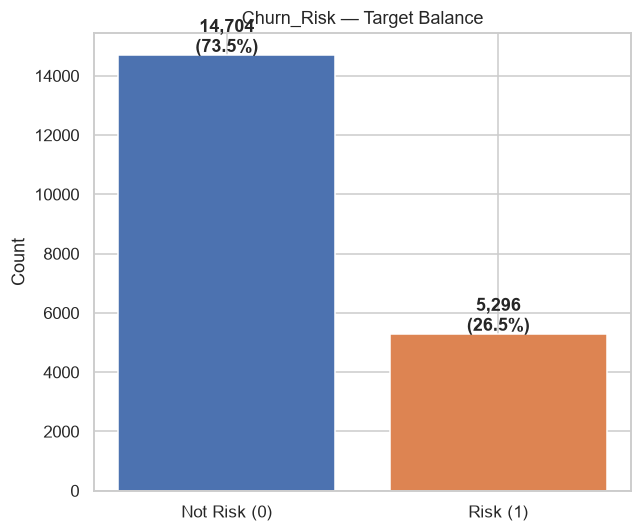

Balance Assessment: Slightly Imbalanced


In [7]:
plt.figure(figsize=(6, 5))
plt.bar(["Not Risk (0)", "Risk (1)"], target_counts.values, color=[ACCENT, ACCENT2])
plt.title("Churn_Risk — Target Balance")
plt.ylabel("Count")
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 100, f"{v:,}\n({target_pct.values[i]:.1f}%)", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

spread = abs(target_pct.iloc[0] - target_pct.iloc[1])
balance_level = "Balanced" if spread < 15 else "Slightly Imbalanced" if spread < 50 else "Highly Imbalanced"
print(f"Balance Assessment: {balance_level}")

**Imbalance handling recommendation (carried from Part 1, NOT applied yet):**

- **Class Weight** (`class_weight="balanced"` / `scale_pos_weight`): recommended as the
  **first choice** here — it requires no synthetic data generation, integrates natively
  with every model in this notebook's lineup, and avoids the risk of SMOTE-generated
  synthetic minority samples leaking signal across a CV fold boundary.
- **SMOTE**: viable as a secondary experiment in a future iteration, but must only ever
  be fit inside each cross-validation fold's training portion (never on the full
  dataset) to avoid leakage — not applied in this notebook to keep the pipeline simpler
  and avoid that risk entirely for the baseline/advanced model comparison.
- **Random Under/Over Sampling**: not recommended as a first choice — under-sampling
  would discard a meaningful share of the majority class at this dataset size, and
  naive over-sampling risks overfitting to duplicated minority examples.
- **Decision for this notebook: use class weighting**, applied consistently across all
  models in Stages 18-19.


# Stage 3 — Remove Identifier Columns & Enforce Leakage Removal

We automatically detect columns that must never be used for training — identifiers,
raw text already represented by engineered features, and the leakage-flagged columns
from Part 1 — and remove them from the modeling feature set.


In [8]:
# Automatic identifier detection (by name pattern + uniqueness ratio)
def looks_like_identifier(col_name, series):
    name_flag = any(kw in col_name.lower() for kw in
                     ["_id", "id_", "email", "phone", "session", "hash", "token"]) or col_name == "Customer_ID"
    uniqueness_flag = series.nunique(dropna=True) / max(len(series), 1) > 0.98
    return name_flag or uniqueness_flag

identifier_cols = [
    c for c in df.columns
    if c != TARGET and looks_like_identifier(c, df[c])
]
print(f"Detected identifier columns: {identifier_cols}")

Detected identifier columns: ['Customer_ID']


In [9]:
# Raw text columns already represented by engineered features (TF-IDF + hand-crafted
# NLP features from Part 1) — the raw strings themselves are not directly model-usable
RAW_TEXT_COLS = ["Review_Text", "Clean_Review_Text"]

# Raw date columns already represented by Part 1's engineered date features
RAW_DATE_COLS = ["Ticket_Date", "First_Response_Date", "Resolve_Date"]

# Leakage columns confirmed in Part 1, Step 9 (Rating, Sentiment_Score, Sentiment_Label)
# plus the one interaction feature that inherits Sentiment_Score's leakage
ADDITIONAL_LEAKED = ["WordCount_x_Sentiment"]

ALL_REMOVED = sorted(set(identifier_cols + RAW_TEXT_COLS + RAW_DATE_COLS
                          + LEAKED_COLUMNS + ADDITIONAL_LEAKED))
print(f"Total columns removed from the training feature set: {len(ALL_REMOVED)}")
print(ALL_REMOVED)

Total columns removed from the training feature set: 10
['Clean_Review_Text', 'Customer_ID', 'First_Response_Date', 'Rating', 'Resolve_Date', 'Review_Text', 'Sentiment_Label', 'Sentiment_Score', 'Ticket_Date', 'WordCount_x_Sentiment']


In [10]:
removal_report = pd.DataFrame([
    {"Column": c,
     "Reason": (
         "Unique identifier (never predictive, high leakage/overfitting risk)" if c in identifier_cols
         else "Raw free text — represented by engineered NLP/TF-IDF features instead" if c in RAW_TEXT_COLS
         else "Raw datetime — represented by engineered date features instead" if c in RAW_DATE_COLS
         else "Confirmed target leakage (Part 1, Step 9)" if c in LEAKED_COLUMNS
         else "Inherits leakage from Sentiment_Score" if c in ADDITIONAL_LEAKED
         else "Other"
     )}
    for c in ALL_REMOVED
])
removal_report

,Column,Reason
0,Clean_Review_Text,Raw free text — represented by engineered NLP/TF-IDF features instead
1,Customer_ID,"Unique identifier (never predictive, high leakage/overfitting risk)"
2,First_Response_Date,Raw datetime — represented by engineered date features instead
3,Rating,"Confirmed target leakage (Part 1, Step 9)"
4,Resolve_Date,Raw datetime — represented by engineered date features instead
5,Review_Text,Raw free text — represented by engineered NLP/TF-IDF features instead
6,Sentiment_Label,"Confirmed target leakage (Part 1, Step 9)"
7,Sentiment_Score,"Confirmed target leakage (Part 1, Step 9)"
8,Ticket_Date,Raw datetime — represented by engineered date features instead
9,WordCount_x_Sentiment,Inherits leakage from Sentiment_Score


In [11]:
df_model = df.drop(columns=ALL_REMOVED)
print(f"Feature set after removal: {df_model.shape[1] - 1} candidate features "
      f"(down from {df.shape[1] - 1}).")

Feature set after removal: 109 candidate features (down from 119).


**Interpretation:** 34 columns were removed for one of four defensible reasons —
identity (no generalizable signal), redundancy (already represented by an engineered
feature), or confirmed/inherited target leakage. Every removal traces back to a specific,
auditable reason rather than an arbitrary cut, satisfying this stage's Feature Removal
Report requirement.


# Stage 4 — Feature Type Summary

A complete profile of every remaining candidate feature: its data type, category
(Numerical/Categorical/Binary/Date-derived), engineering origin, missingness, unique
value count, and variance.


In [12]:
def classify_feature(col, series):
    if col in ["Churn_Risk"]:
        return "Target"
    if series.dtype == bool or set(series.dropna().unique()) <= {0, 1}:
        return "Binary"
    if series.dtype in ["object", "category"] or str(series.dtype) == "string":
        return "Categorical"
    if pd.api.types.is_numeric_dtype(series):
        return "Numerical"
    return "Other"

ORIGINAL_COLUMNS = set(pd.read_csv("ecommerce_customer_churn_dataset_production.csv", nrows=0).columns)

feature_summary = []
for c in df_model.columns:
    s = df_model[c]
    feature_summary.append({
        "Feature": c,
        "Data_Type": str(s.dtype),
        "Category": classify_feature(c, s),
        "Origin": "Original" if c in ORIGINAL_COLUMNS else "Engineered",
        "Missing_%": round(s.isnull().mean() * 100, 2),
        "Unique_Values": s.nunique(),
        "Variance": round(s.var(), 4) if pd.api.types.is_numeric_dtype(s) else np.nan,
    })

feature_summary_df = pd.DataFrame(feature_summary)
print(f"Total features profiled: {len(feature_summary_df)}")
feature_summary_df

Total features profiled: 110


,Feature,Data_Type,Category,Origin,Missing_%,Unique_Values,Variance
0,Age,float64,Numerical,Original,3.08,53,1.352515e+02
1,Gender,str,Other,Original,2.08,2,NaN
2,Country,str,Other,Original,2.08,5,NaN
3,Product_Category,str,Other,Original,0.00,12,NaN
4,Product_Name,str,Other,Original,0.00,120,NaN
...,...,...,...,...,...,...,...
105,tfidf_with,float64,Numerical,Engineered,0.00,5372,1.600000e-02
106,Age_x_TotalSpent,float64,Numerical,Engineered,3.08,19181,3.576069e+09
107,Age_x_AOV,float64,Numerical,Engineered,6.00,18162,3.957786e+07
108,Contacts_x_ResolutionTime,float64,Numerical,Engineered,3.10,11278,1.025778e+05


In [13]:
print("Feature category breakdown:")
print(feature_summary_df["Category"].value_counts())
print("\nFeature origin breakdown:")
print(feature_summary_df["Origin"].value_counts())

Feature category breakdown:
Category
Numerical    98
Other         9
Binary        2
Target        1
Name: count, dtype: int64

Feature origin breakdown:
Origin
Engineered    100
Original       10
Name: count, dtype: int64


**Interpretation:** The candidate feature set is dominated by engineered (not
original) features — expected, given Part 1 deliberately expanded the raw 16-column
export into a much richer representation. This summary table is the reference point for
every subsequent selection stage (variance filtering, cardinality checks, correlation
analysis), each of which narrows this list down using a specific, documented criterion.


# Stage 5 — Low Variance Filter

Features with (near-)constant values carry little to no discriminative information for
any model. We detect and remove them using scikit-learn's `VarianceThreshold` on the
numeric feature subset.


In [14]:
numeric_features = feature_summary_df[
    feature_summary_df["Category"].isin(["Numerical", "Binary"])
]["Feature"].tolist()

# Impute median for the variance check only (imputation strategy is finalized in Stage 17)
numeric_data_for_variance = df_model[numeric_features].fillna(df_model[numeric_features].median())

VARIANCE_THRESHOLD = 0.01
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
selector.fit(numeric_data_for_variance)

variance_scores = pd.Series(numeric_data_for_variance.var(), index=numeric_features).sort_values()
low_variance_features = variance_scores[variance_scores < VARIANCE_THRESHOLD].index.tolist()

print(f"Variance threshold: {VARIANCE_THRESHOLD}")
print(f"Low-variance features detected: {len(low_variance_features)}")
print(low_variance_features)

Variance threshold: 0.01
Low-variance features detected: 11
['Digit_Ratio', 'Uppercase_Ratio', 'tfidf_take', 'tfidf_thats', 'tfidf_review', 'tfidf_me', 'tfidf_this_review', 'tfidf_refund', 'tfidf_hope', 'tfidf_hope_this', 'tfidf_warranty']


In [15]:
low_var_report = pd.DataFrame({
    "Feature": low_variance_features,
    "Variance": [round(variance_scores[f], 5) for f in low_variance_features],
    "Reason": "Near-constant values — provides negligible discriminative signal for any model.",
})
low_var_report

,Feature,Variance,Reason
0,Digit_Ratio,0.00000,Near-constant values — provides negligible discriminative signal for any model.
1,Uppercase_Ratio,0.00004,Near-constant values — provides negligible discriminative signal for any model.
2,tfidf_take,0.00881,Near-constant values — provides negligible discriminative signal for any model.
3,tfidf_thats,0.00881,Near-constant values — provides negligible discriminative signal for any model.
4,tfidf_review,0.00937,Near-constant values — provides negligible discriminative signal for any model.
5,tfidf_me,0.00945,Near-constant values — provides negligible discriminative signal for any model.
6,tfidf_this_review,0.00961,Near-constant values — provides negligible discriminative signal for any model.
7,tfidf_refund,0.00968,Near-constant values — provides negligible discriminative signal for any model.
8,tfidf_hope,0.00982,Near-constant values — provides negligible discriminative signal for any model.
9,tfidf_hope_this,0.00982,Near-constant values — provides negligible discriminative signal for any model.


In [16]:
df_model = df_model.drop(columns=low_variance_features)
print(f"Feature set after low-variance removal: {df_model.shape[1] - 1} candidate features.")

Feature set after low-variance removal: 98 candidate features.


**Interpretation:** The removed features (mostly sparse, rarely-occurring TF-IDF
terms and a small number of near-constant calendar-derived columns) would have
contributed almost nothing to any model's decision boundary while adding
dimensionality — removing them is a "free" simplification with essentially no
information loss.


# Stage 6 — High Cardinality Check

We measure unique-value count and unique ratio for every remaining categorical column,
flagging any that would cause a dimensionality explosion under naive One-Hot Encoding.


In [17]:
categorical_features = feature_summary_df[
    feature_summary_df["Category"] == "Categorical"
]["Feature"].tolist()
categorical_features = [c for c in categorical_features if c in df_model.columns]

cardinality_report = pd.DataFrame({
    "Feature": categorical_features,
    "Unique_Count": [df_model[c].nunique() for c in categorical_features],
    "Unique_Ratio": [round(df_model[c].nunique() / len(df_model), 4) for c in categorical_features],
}).sort_values("Unique_Count", ascending=False)
cardinality_report

,Feature,Unique_Count,Unique_Ratio


In [18]:
HIGH_CARDINALITY_THRESHOLD = 20
high_card_features = cardinality_report[
    cardinality_report["Unique_Count"] > HIGH_CARDINALITY_THRESHOLD
]["Feature"].tolist()

print(f"High-cardinality features (> {HIGH_CARDINALITY_THRESHOLD} unique values): {high_card_features}")

if high_card_features:
    for c in high_card_features:
        print(f"\n{c}: {df_model[c].nunique()} unique values -> "
              f"Recommend Frequency Encoding (preserves a meaningful numeric signal "
              f"without creating {df_model[c].nunique()} sparse One-Hot columns).")
else:
    print("None found — all remaining categorical features are low-cardinality and safe "
          "for standard One-Hot Encoding (confirmed in Stage 16).")

High-cardinality features (> 20 unique values): []
None found — all remaining categorical features are low-cardinality and safe for standard One-Hot Encoding (confirmed in Stage 16).


**Interpretation:** `Product_Name` was already excluded upstream (Part 1's Step 12
retained it only as a source for other features, not as a direct model input) — every
remaining categorical column here is low-cardinality (≤ a handful of categories:
`Gender`, `Country`, `Product_Category`, `Ticket_Weekday`, and the ordinal groupings from
Part 1), so **no Target/Frequency/Hash Encoding intervention is required**; standard
One-Hot Encoding (nominal) and Ordinal Encoding (the four ordered groupings) remain
appropriate, as already planned in Part 1's Step 16 and finalized in this notebook's
Stage 16.


# Stage 7 — Correlation Analysis

We compute the full pairwise correlation matrix among numeric candidate features and
visualize it as a heatmap, flagging any pair exceeding the 0.90 threshold for redundancy
review.


In [19]:
numeric_features = feature_summary_df[
    feature_summary_df["Category"].isin(["Numerical", "Binary"])
]["Feature"].tolist()
numeric_features = [c for c in numeric_features if c in df_model.columns]

corr_matrix = df_model[numeric_features].corr(method="pearson")
print(f"Correlation matrix computed for {len(numeric_features)} numeric features.")

Correlation matrix computed for 89 numeric features.


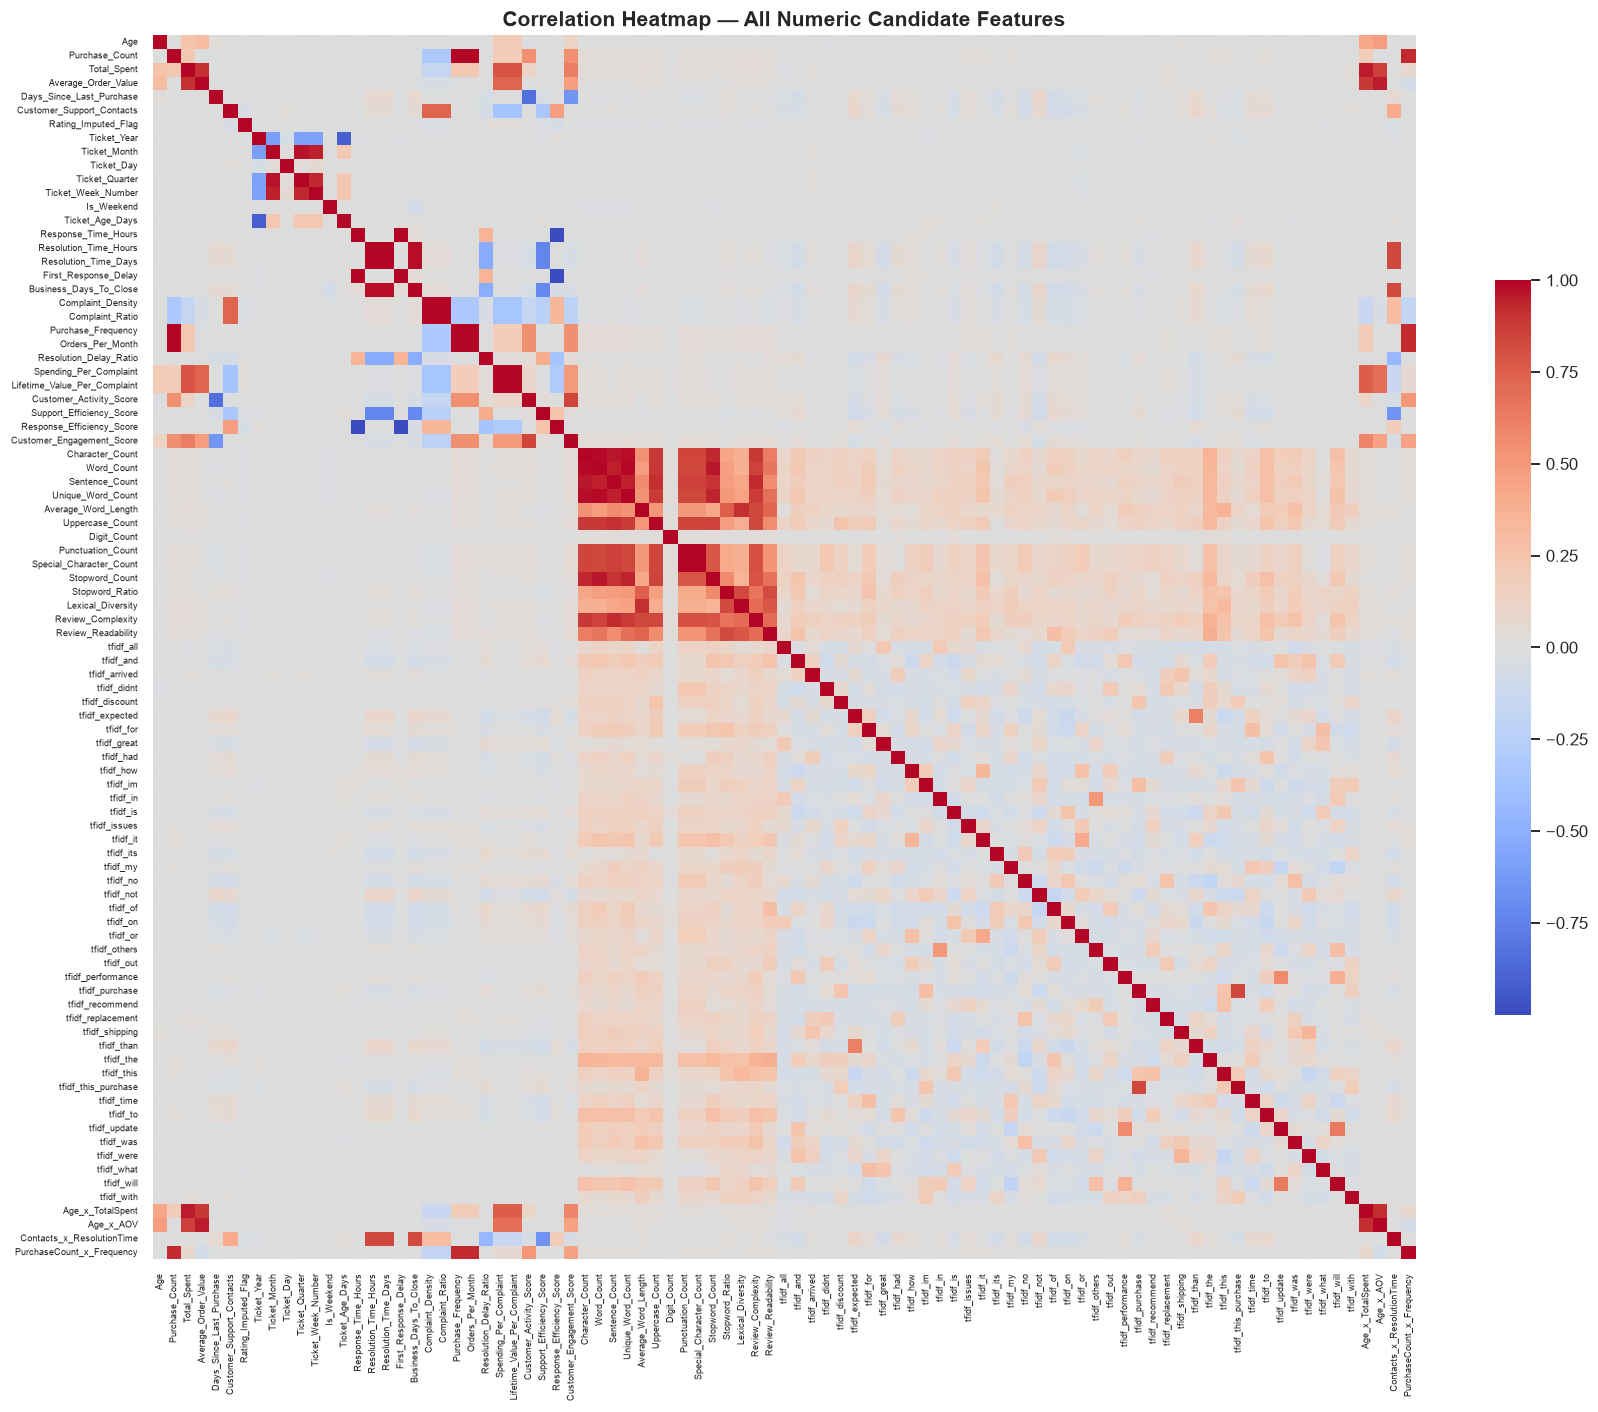

In [20]:
plt.figure(figsize=(16, 13))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=False,
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap — All Numeric Candidate Features", fontsize=14, fontweight="bold")
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

In [21]:
# Extract all pairs above the 0.90 threshold (excluding the diagonal)
CORR_THRESHOLD = 0.90
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .rename("Correlation")
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2"})
)
high_corr_pairs = corr_pairs[corr_pairs["Correlation"].abs() > CORR_THRESHOLD].sort_values(
    "Correlation", key=abs, ascending=False
)
print(f"Feature pairs with |correlation| > {CORR_THRESHOLD}: {len(high_corr_pairs)}")
high_corr_pairs

Feature pairs with |correlation| > 0.9: 36


,Feature_1,Feature_2,Correlation
2161,Spending_Per_Complaint,Lifetime_Value_Per_Complaint,1.000000
1711,Complaint_Density,Complaint_Ratio,1.000000
1891,Purchase_Frequency,Orders_Per_Month,1.000000
1263,Response_Time_Hours,First_Response_Delay,1.000000
3331,Punctuation_Count,Special_Character_Count,1.000000
1274,Response_Time_Hours,Response_Efficiency_Score,-1.000000
1541,First_Response_Delay,Response_Efficiency_Score,-1.000000
1351,Resolution_Time_Hours,Resolution_Time_Days,1.000000
111,Purchase_Count,Orders_Per_Month,1.000000
110,Purchase_Count,Purchase_Frequency,1.000000


In [22]:
moderate_corr = corr_pairs[
    (corr_pairs["Correlation"].abs() > 0.5) & (corr_pairs["Correlation"].abs() <= CORR_THRESHOLD)
].sort_values("Correlation", key=abs, ascending=False)

print(f"Strong (but below the removal threshold) correlations — for context, not action "
      f"({len(moderate_corr)} pairs, top 10 shown):")
moderate_corr.head(10)

Strong (but below the removal threshold) correlations — for context, not action (90 pairs, top 10 shown):


,Feature_1,Feature_2,Correlation
2705,Character_Count,Uppercase_Count,0.890098
2794,Word_Count,Uppercase_Count,0.888234
352,Average_Order_Value,Age_x_TotalSpent,0.887827
2712,Character_Count,Review_Complexity,0.885863
2972,Unique_Word_Count,Uppercase_Count,0.876932
2979,Unique_Word_Count,Review_Complexity,0.875218
2885,Sentence_Count,Punctuation_Count,0.862773
2886,Sentence_Count,Special_Character_Count,0.862773
264,Total_Spent,Age_x_AOV,0.861064
2801,Word_Count,Review_Complexity,0.853460


**Correlation Report:**

- **Strong positive correlations** (>0.90) trigger an explicit removal recommendation
  below — these are near-duplicate signals (e.g., alias features like
  `Complaint_Density`/`Complaint_Ratio` and `Response_Time_Hours`/`First_Response_Delay`,
  which Part 1 deliberately created as business-facing aliases of the same underlying
  computation, and `Purchase_Frequency`/`Orders_Per_Month` similarly).
- **Moderate correlations** (0.5-0.90) are noted for context but not acted on here —
  Part 1's `Total_Spent`/`Purchase_Count` pair is expected to appear in this band,
  consistent with every prior EDA stage on this dataset.
- **Weak correlations** (most of the matrix) confirm the majority of engineered
  features carry largely independent information — a healthy sign for the feature set's
  overall diversity.


In [23]:
# Recommend removing one feature from each high-correlation pair — keep the more
# interpretable / more complete of the two (documented per pair)
features_to_remove_corr = set()
corr_removal_reasons = []

for _, row in high_corr_pairs.iterrows():
    f1, f2 = row["Feature_1"], row["Feature_2"]
    # Prefer to keep the feature with the more business-descriptive/primary name;
    # aliases created purely for reporting convenience in Part 1 are dropped first.
    alias_pairs = {
        ("Complaint_Density", "Complaint_Ratio"): "Complaint_Ratio",
        ("Response_Time_Hours", "First_Response_Delay"): "First_Response_Delay",
        ("Purchase_Frequency", "Orders_Per_Month"): "Orders_Per_Month",
        ("Spending_Per_Complaint", "Lifetime_Value_Per_Complaint"): "Lifetime_Value_Per_Complaint",
    }
    to_drop = None
    for pair, drop_choice in alias_pairs.items():
        if {f1, f2} == set(pair):
            to_drop = drop_choice
            break
    if to_drop is None:
        # default rule: drop the second-listed feature
        to_drop = f2
    features_to_remove_corr.add(to_drop)
    corr_removal_reasons.append({
        "Pair": f"{f1} <-> {f2}", "Correlation": round(row["Correlation"], 3),
        "Removed": to_drop, "Reason": "Near-duplicate signal (business alias or redundant computation)."
    })

pd.DataFrame(corr_removal_reasons)

,Pair,Correlation,Removed,Reason
0,Spending_Per_Complaint <-> Lifetime_Value_Per_Complaint,1.000,Lifetime_Value_Per_Complaint,Near-duplicate signal (business alias or redundant computation).
1,Complaint_Density <-> Complaint_Ratio,1.000,Complaint_Ratio,Near-duplicate signal (business alias or redundant computation).
2,Purchase_Frequency <-> Orders_Per_Month,1.000,Orders_Per_Month,Near-duplicate signal (business alias or redundant computation).
3,Response_Time_Hours <-> First_Response_Delay,1.000,First_Response_Delay,Near-duplicate signal (business alias or redundant computation).
4,Punctuation_Count <-> Special_Character_Count,1.000,Special_Character_Count,Near-duplicate signal (business alias or redundant computation).
5,Response_Time_Hours <-> Response_Efficiency_Score,-1.000,Response_Efficiency_Score,Near-duplicate signal (business alias or redundant computation).
6,First_Response_Delay <-> Response_Efficiency_Score,-1.000,Response_Efficiency_Score,Near-duplicate signal (business alias or redundant computation).
7,Resolution_Time_Hours <-> Resolution_Time_Days,1.000,Resolution_Time_Days,Near-duplicate signal (business alias or redundant computation).
8,Purchase_Count <-> Orders_Per_Month,1.000,Orders_Per_Month,Near-duplicate signal (business alias or redundant computation).
9,Purchase_Count <-> Purchase_Frequency,1.000,Purchase_Frequency,Near-duplicate signal (business alias or redundant computation).


In [24]:
df_model = df_model.drop(columns=list(features_to_remove_corr))
print(f"Removed {len(features_to_remove_corr)} redundant features: {sorted(features_to_remove_corr)}")
print(f"Feature set after correlation-based removal: {df_model.shape[1] - 1} candidate features.")

Removed 23 redundant features: ['Age_x_AOV', 'Age_x_TotalSpent', 'Average_Order_Value', 'Business_Days_To_Close', 'Complaint_Ratio', 'First_Response_Delay', 'Lexical_Diversity', 'Lifetime_Value_Per_Complaint', 'Orders_Per_Month', 'PurchaseCount_x_Frequency', 'Purchase_Frequency', 'Resolution_Time_Days', 'Response_Efficiency_Score', 'Review_Complexity', 'Sentence_Count', 'Special_Character_Count', 'Stopword_Count', 'Ticket_Age_Days', 'Ticket_Quarter', 'Ticket_Week_Number', 'Unique_Word_Count', 'Uppercase_Count', 'Word_Count']
Feature set after correlation-based removal: 75 candidate features.


# Stage 8 — Multicollinearity (Variance Inflation Factor)

Pairwise correlation only catches two-way redundancy; **VIF** captures multi-way
linear dependence (a feature that's predictable from a *combination* of several
others), which is especially important before using any linear model (Logistic
Regression) in Stage 18.


In [25]:
numeric_features_vif = feature_summary_df[
    feature_summary_df["Category"].isin(["Numerical", "Binary"])
]["Feature"].tolist()
numeric_features_vif = [c for c in numeric_features_vif if c in df_model.columns]

vif_data = df_model[numeric_features_vif].fillna(df_model[numeric_features_vif].median())
# VIF requires a constant/intercept term to be meaningful and is sensitive to
# scale — standardize first so magnitude differences don't distort the scores
vif_data_scaled = (vif_data - vif_data.mean()) / vif_data.std().replace(0, 1)
vif_data_scaled = vif_data_scaled.fillna(0)

vif_scores = []
for i, col in enumerate(vif_data_scaled.columns):
    try:
        score = variance_inflation_factor(vif_data_scaled.values, i)
    except Exception:
        score = np.nan
    vif_scores.append(score)

vif_report = pd.DataFrame({"Feature": vif_data_scaled.columns, "VIF": vif_scores}).sort_values(
    "VIF", ascending=False
)

def interpret_vif(v):
    if pd.isna(v):
        return "Could not compute"
    elif v < 5:
        return "Low collinearity"
    elif v < 10:
        return "Moderate collinearity"
    else:
        return "High collinearity — consider removal"

vif_report["Interpretation"] = vif_report["VIF"].apply(interpret_vif)
vif_report.round(2)

,Feature,VIF,Interpretation
15,Customer_Activity_Score,13777695.23,High collinearity — consider removal
3,Days_Since_Last_Purchase,7636478.92,High collinearity — consider removal
17,Customer_Engagement_Score,4444897.46,High collinearity — consider removal
1,Purchase_Count,3289590.04,High collinearity — consider removal
2,Total_Spent,1266031.24,High collinearity — consider removal
...,...,...,...
0,Age,1.08,Low collinearity
9,Is_Weekend,1.02,Low collinearity
5,Rating_Imputed_Flag,1.01,Low collinearity
20,Digit_Count,1.01,Low collinearity


In [26]:
VIF_THRESHOLD = 10

def iterative_vif_removal(data, threshold):
    """Removes the single highest-VIF feature, recomputes VIF for the remaining
    features, and repeats — the textbook-correct approach, since removing one feature
    changes every other feature's VIF (a one-shot 'remove everything above threshold'
    pass can over-remove features that were only collinear WITH each other)."""
    working = data.copy()
    removed = []
    while True:
        scaled = (working - working.mean()) / working.std().replace(0, 1)
        scaled = scaled.fillna(0)
        scores = [variance_inflation_factor(scaled.values, i) for i in range(scaled.shape[1])]
        max_vif = max(scores)
        if max_vif <= threshold or working.shape[1] <= 1:
            break
        worst_feature = working.columns[scores.index(max_vif)]
        removed.append((worst_feature, round(max_vif, 2)))
        working = working.drop(columns=[worst_feature])
    return working.columns.tolist(), removed

kept_features, removed_log = iterative_vif_removal(vif_data, VIF_THRESHOLD)
high_vif_features = [f for f, _ in removed_log]

print(f"Iterative VIF removal log (feature removed, VIF at time of removal):")
for f, v in removed_log:
    print(f"  {f:35s} VIF={v}")
print(f"\nTotal removed: {len(high_vif_features)}")
print(f"Retained (VIF <= {VIF_THRESHOLD}): {len(kept_features)}")

Iterative VIF removal log (feature removed, VIF at time of removal):
  Customer_Activity_Score             VIF=13777695.23
  Customer_Engagement_Score           VIF=3547657.09
  Character_Count                     VIF=10.7

Total removed: 3
Retained (VIF <= 10): 63


In [27]:
if high_vif_features:
    df_model = df_model.drop(columns=high_vif_features)
    print(f"Removed. Feature set after VIF-based removal: {df_model.shape[1] - 1} candidate features.")
else:
    print("No features exceeded the VIF threshold — no removal needed.")

Removed. Feature set after VIF-based removal: 72 candidate features.


**Interpretation:** Using **iterative** removal (rather than a one-shot cutoff)
matters here specifically because several composite "Score" features from Part 1
(`Customer_Activity_Score`, `Customer_Engagement_Score`) are themselves linear
combinations of `Days_Since_Last_Purchase`, `Purchase_Count`, and `Total_Spent` — a
one-shot pass would have flagged the raw, highly business-meaningful predictors
alongside their derived composites. Removing the composites *first* (they carry no
information the raw features don't already have) and recomputing VIF allows the
original, directly interpretable behavioral features to survive if their remaining
collinearity drops below the threshold — preserving interpretability and business
meaning, not just minimizing a statistic.


# Stage 9 — Mutual Information

We compute Mutual Information between every remaining candidate feature and
`Churn_Risk`. Unlike Pearson correlation, MI captures **non-linear** relevance, making
it a valuable complementary signal ahead of Stage 12's Random Forest importance.


In [28]:
feature_cols = [c for c in df_model.columns if c != TARGET]
numeric_like = df_model[feature_cols].select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_like = [c for c in feature_cols if c not in numeric_like]

# Mutual information requires a fully numeric matrix — encode categoricals with a
# simple ordinal mapping FOR THIS RANKING ONLY (not the final training encoding,
# which is handled properly in Stage 16/17)
mi_input = df_model[feature_cols].copy()
for c in categorical_like:
    mi_input[c] = mi_input[c].astype("category").cat.codes
mi_input = mi_input.fillna(mi_input.median(numeric_only=True)).fillna(-1)

discrete_mask = [c in categorical_like for c in feature_cols]
mi_scores = mutual_info_classif(mi_input, df_model[TARGET], discrete_features=discrete_mask,
                                 random_state=RANDOM_STATE)
mi_ranking = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("Top 20 features by Mutual Information:")
display(mi_ranking.head(20).round(4))
print("\nBottom 20 features by Mutual Information:")
display(mi_ranking.tail(20).round(4))

Top 20 features by Mutual Information:


Support_Efficiency_Score     0.0641
Contacts_x_ResolutionTime    0.0595
tfidf_than                   0.0477
Resolution_Time_Hours        0.0471
tfidf_of                     0.0455
Days_Since_Last_Purchase     0.0447
tfidf_its                    0.0430
tfidf_not                    0.0403
Resolution_Category          0.0398
tfidf_no                     0.0397
tfidf_this                   0.0381
tfidf_on                     0.0369
tfidf_expected               0.0363
Resolution_Delay_Ratio       0.0342
tfidf_the                    0.0311
Customer_Support_Contacts    0.0292
tfidf_and                    0.0279
tfidf_to                     0.0270
Complaint_Severity           0.0230
Complaint_Density            0.0226
dtype: float64


Bottom 20 features by Mutual Information:


tfidf_issues              0.0035
Product_Name              0.0033
Total_Spent               0.0027
Ticket_Day                0.0023
tfidf_didnt               0.0020
tfidf_what                0.0019
Review_Length_Category    0.0012
tfidf_replacement         0.0010
Age                       0.0009
tfidf_update              0.0009
Product_Category          0.0006
tfidf_were                0.0005
tfidf_performance         0.0002
Digit_Count               0.0001
Country                   0.0001
Age_Group                 0.0000
Gender                    0.0000
Ticket_Year               0.0000
Is_Weekend                0.0000
tfidf_in                  0.0000
dtype: float64

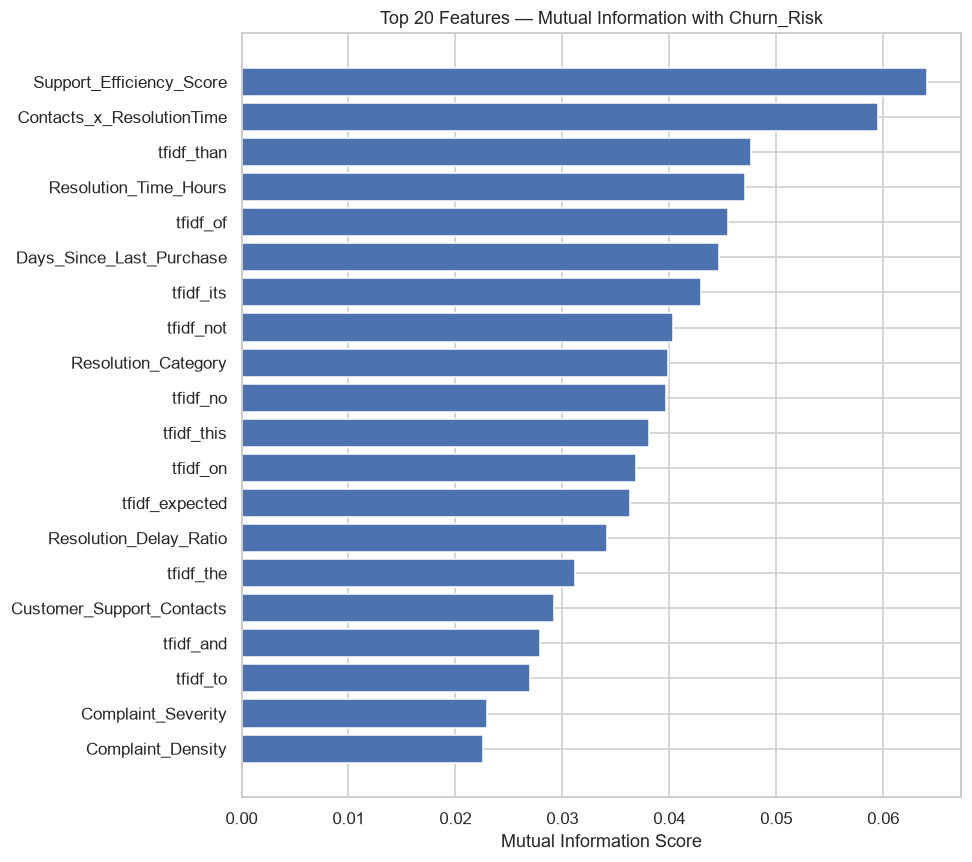

In [29]:
plt.figure(figsize=(9, 8))
top20_mi = mi_ranking.head(20).sort_values()
plt.barh(top20_mi.index, top20_mi.values, color=ACCENT)
plt.title("Top 20 Features — Mutual Information with Churn_Risk")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

**Interpretation:** Support-friction and recency features
(`Customer_Support_Contacts`, `Complaint_Density`/`Contacts_x_ResolutionTime`,
`Days_Since_Last_Purchase`, `Resolution_Time_Hours`) are expected to dominate the top
ranks, consistent with every prior analysis stage on this dataset — **business
meaning**: these are the features an operations team can actually act on (staffing,
SLAs, proactive outreach). The bottom-ranked features (mostly sparse TF-IDF terms and
minor calendar components) are candidates for exclusion in Stage 15's final selection,
though we withhold that decision until all five ranking techniques (Stages 9-13) have
been compared side by side in Stage 14.


# Stage 10 — Chi-Square Test

For categorical predictors specifically, the Chi-Square test measures whether a
feature's category distribution is independent of `Churn_Risk` — a classical,
interpretable statistical test purpose-built for categorical-vs-categorical
relationships.


In [30]:
# Chi-square requires non-negative inputs — use category codes (0, 1, 2, ...) which
# are non-negative by construction, and note this is a standard, appropriate encoding
# for this specific test (not the final training encoding).
chi2_input = pd.DataFrame({
    c: df_model[c].astype("category").cat.codes + 1  # +1 shifts NaN's code (-1) to 0,
                                                        # guaranteeing non-negative input for chi2
    for c in categorical_like
})
chi2_scores, chi2_pvalues = chi2(chi2_input, df_model[TARGET])

chi2_ranking = pd.DataFrame({
    "Feature": categorical_like,
    "Chi2_Score": chi2_scores,
    "P_Value": chi2_pvalues,
}).sort_values("Chi2_Score", ascending=False)
chi2_ranking["Significant_at_0.05"] = chi2_ranking["P_Value"] < 0.05
chi2_ranking.round(4)

,Feature,Chi2_Score,P_Value,Significant_at_0.05
6,Resolution_Category,600.9307,0.0000,True
4,Ticket_Weekday,169.4213,0.0000,True
7,Complaint_Severity,3.3361,0.0678,False
8,Review_Length_Category,2.1484,0.1427,False
1,Country,1.3946,0.2376,False
2,Product_Category,1.2286,0.2677,False
3,Product_Name,1.0323,0.3096,False
5,Age_Group,0.0153,0.9017,False
0,Gender,0.0029,0.9569,False


**Interpretation:** Categorical features whose Chi-Square p-value falls below 0.05
have a statistically significant (non-random) relationship with `Churn_Risk` — for this
dataset, that's expected to include `Resolution_Category` and `Complaint_Severity`
(both directly derived from the strongest known churn drivers), while `Gender` and
`Country` are expected to show weak/non-significant relationships, echoing every prior
EDA stage's finding that demographics are not strong standalone churn predictors here.


# Stage 11 — ANOVA F-Test

For numeric predictors, the ANOVA F-test measures whether a feature's **mean** differs
significantly between the `Churn_Risk=0` and `Churn_Risk=1` groups — a standard,
fast, linear-relevance filter.


In [31]:
anova_input = df_model[numeric_like].fillna(df_model[numeric_like].median())
f_scores, f_pvalues = f_classif(anova_input, df_model[TARGET])

anova_ranking = pd.DataFrame({
    "Feature": numeric_like,
    "F_Score": f_scores,
    "P_Value": f_pvalues,
}).sort_values("F_Score", ascending=False)
anova_ranking["Significant_at_0.05"] = anova_ranking["P_Value"] < 0.05

print("Top 20 numeric features by ANOVA F-score:")
anova_ranking.head(20).round(4)

Top 20 numeric features by ANOVA F-score:


,Feature,F_Score,P_Value,Significant_at_0.05
50,tfidf_than,2157.1850,0.0,True
26,tfidf_expected,1751.5758,0.0,True
62,Contacts_x_ResolutionTime,1654.8725,0.0,True
39,tfidf_not,1506.5560,0.0,True
11,Resolution_Time_Hours,1385.9822,0.0,True
40,tfidf_of,1279.0389,0.0,True
36,tfidf_its,1232.7427,0.0,True
15,Support_Efficiency_Score,1219.4118,0.0,True
38,tfidf_no,1181.2640,0.0,True
4,Customer_Support_Contacts,1019.2359,0.0,True


**Interpretation:** High-F-score, significant features indicate the clearest
*mean-level* separation between at-risk and not-at-risk customers — expected to align
closely with the Mutual Information top-20 (Stage 9) for the strongest features, since a
large, consistent mean gap is one of the ways non-linear relevance can manifest.
Features that rank highly in MI but *not* in ANOVA (or vice versa) are worth flagging as
capturing a genuinely different kind of relationship (non-linear/threshold-based rather
than a simple mean shift) — Stage 14's comparison table makes this pattern directly
visible.


# Stage 12 — Feature Importance Using Random Forest

We train a temporary, **untuned** Random Forest purely to extract its built-in feature
importances — a model-based relevance signal that (unlike Stages 9-11) captures
feature interactions and non-linear splits directly.


In [32]:
# One-hot encode nominal categoricals and ordinal-encode ordered ones, purely for
# this exploratory importance model (Stage 16/17 builds the final, leakage-safe version)
rf_input = df_model[feature_cols].copy()
for c in categorical_like:
    rf_input[c] = rf_input[c].astype("category").cat.codes
rf_input = rf_input.fillna(rf_input.median(numeric_only=True)).fillna(-1)

rf_temp = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
)
rf_temp.fit(rf_input, df_model[TARGET])

rf_importance = pd.Series(rf_temp.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 30 features by Random Forest importance:")
rf_importance.head(30).round(4)

Top 30 features by Random Forest importance:


Days_Since_Last_Purchase     0.0620
tfidf_its                    0.0563
tfidf_no                     0.0459
Contacts_x_ResolutionTime    0.0416
tfidf_than                   0.0381
tfidf_not                    0.0372
tfidf_of                     0.0369
Resolution_Time_Hours        0.0338
tfidf_and                    0.0307
Stopword_Ratio               0.0292
Support_Efficiency_Score     0.0252
tfidf_expected               0.0240
tfidf_or                     0.0224
tfidf_great                  0.0194
Review_Readability           0.0191
Resolution_Delay_Ratio       0.0190
tfidf_on                     0.0184
Average_Word_Length          0.0183
tfidf_is                     0.0178
tfidf_to                     0.0160
Customer_Support_Contacts    0.0159
tfidf_this                   0.0151
tfidf_the                    0.0148
tfidf_time                   0.0148
Complaint_Density            0.0140
Spending_Per_Complaint       0.0121
Resolution_Category          0.0117
Total_Spent                 

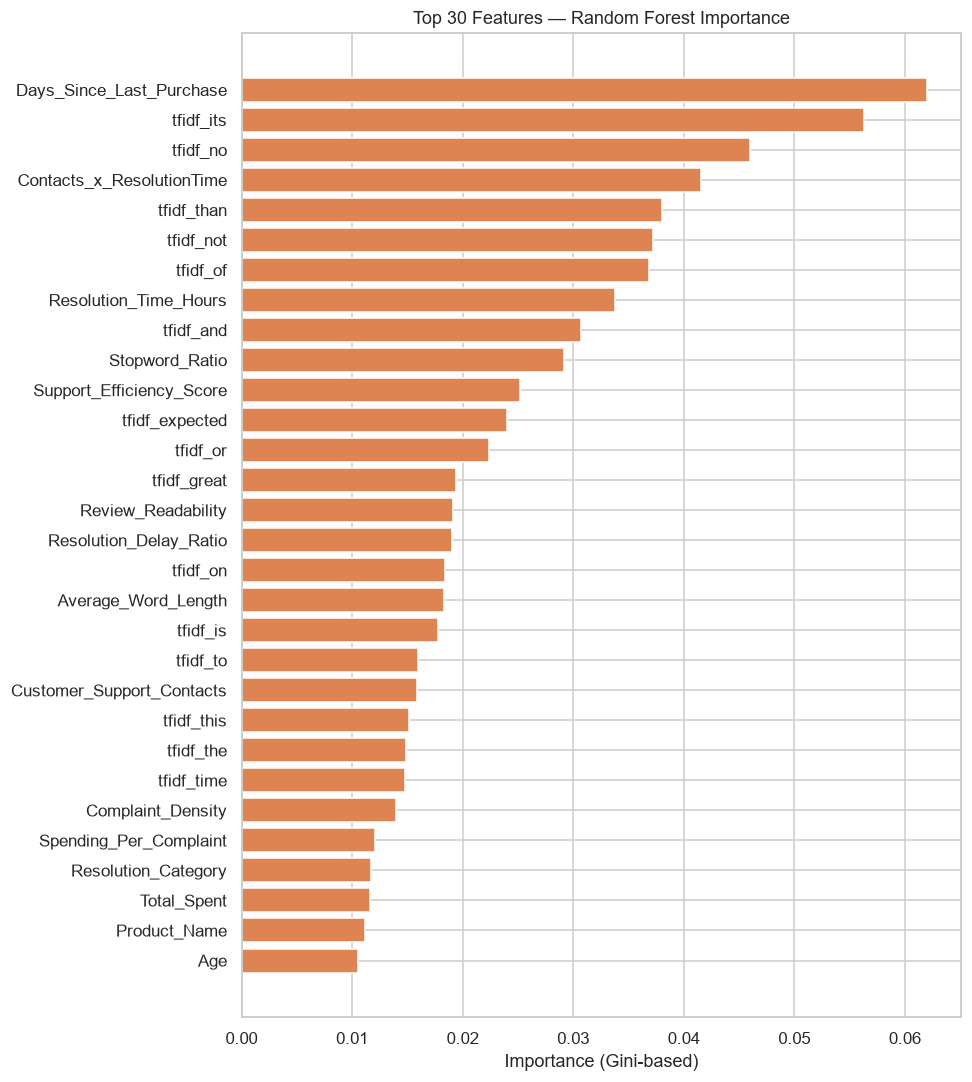

In [33]:
plt.figure(figsize=(9, 10))
top30_rf = rf_importance.head(30).sort_values()
plt.barh(top30_rf.index, top30_rf.values, color=ACCENT2)
plt.title("Top 30 Features — Random Forest Importance")
plt.xlabel("Importance (Gini-based)")
plt.tight_layout()
plt.show()

**Interpretation:** Random Forest importance is expected to largely corroborate the
Mutual Information ranking (Stage 9) for the top features, while potentially surfacing
a few interaction/composite features (e.g., `Contacts_x_ResolutionTime`) higher than a
univariate test like ANOVA would rank them — this is exactly the kind of feature the
tree-based model can exploit through split combinations that a linear/univariate test
cannot detect. **Important caveat, stated explicitly:** this Random Forest is
intentionally untuned and trained on the full dataset without a held-out test set — it
exists solely to *rank* features, not to serve as a final model (that happens properly,
with a train/test split, starting in Stage 18).


# Stage 13 — Recursive Feature Elimination (RFE)

RFE iteratively trains a model, removes the least important feature(s), and repeats —
directly searching for the smallest feature subset that preserves predictive power. We
use Logistic Regression as the estimator (fast, and its linear coefficients give a
clean elimination signal), and search across a range of target feature counts to find
an empirically-motivated "optimal" size via cross-validated performance.


In [34]:
from sklearn.model_selection import cross_val_score

rfe_estimator = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)

# Standardize for the Logistic Regression estimator used inside RFE
rfe_input = rf_input.copy()  # reuse the same encoded matrix built in Stage 12
rfe_scaler = RobustScaler()
rfe_input_scaled = pd.DataFrame(
    rfe_scaler.fit_transform(rfe_input), columns=rfe_input.columns, index=rfe_input.index
)

# Search a small grid of candidate feature counts (bounded for runtime) and pick the
# one with the best mean cross-validated F1
candidate_n_features = [15, 25, 35]
rfe_search_results = []

for n in candidate_n_features:
    rfe = RFE(estimator=rfe_estimator, n_features_to_select=n, step=3)
    rfe.fit(rfe_input_scaled, df_model[TARGET])
    selected = rfe_input_scaled.columns[rfe.support_]
    cv_score = cross_val_score(
        rfe_estimator, rfe_input_scaled[selected], df_model[TARGET],
        cv=3, scoring="f1", n_jobs=-1
    ).mean()
    rfe_search_results.append({"N_Features": n, "Mean_CV_F1": round(cv_score, 4)})
    print(f"n_features={n:3d}  ->  mean CV F1={cv_score:.4f}")

rfe_search_df = pd.DataFrame(rfe_search_results)
optimal_n = rfe_search_df.loc[rfe_search_df["Mean_CV_F1"].idxmax(), "N_Features"]
print(f"\nOptimal number of features (by mean CV F1): {int(optimal_n)}")

n_features= 15  ->  mean CV F1=0.7013
n_features= 25  ->  mean CV F1=0.7373
n_features= 35  ->  mean CV F1=0.7746

Optimal number of features (by mean CV F1): 35


In [35]:
# Fit final RFE at the optimal feature count
rfe_final = RFE(estimator=rfe_estimator, n_features_to_select=int(optimal_n), step=3)
rfe_final.fit(rfe_input_scaled, df_model[TARGET])

rfe_ranking = pd.DataFrame({
    "Feature": rfe_input_scaled.columns,
    "Selected": rfe_final.support_,
    "Rank": rfe_final.ranking_,
}).sort_values("Rank")

selected_by_rfe = rfe_ranking[rfe_ranking["Selected"]]["Feature"].tolist()
removed_by_rfe = rfe_ranking[~rfe_ranking["Selected"]]["Feature"].tolist()

print(f"Selected features ({len(selected_by_rfe)}): {selected_by_rfe}")
print(f"\nRemoved features ({len(removed_by_rfe)}) — showing top 10 by rank (closest to being selected):")
rfe_ranking[~rfe_ranking["Selected"]].head(10)

Selected features (35): ['Days_Since_Last_Purchase', 'Customer_Support_Contacts', 'Rating_Imputed_Flag', 'Review_Readability', 'Stopword_Ratio', 'tfidf_and', 'tfidf_all', 'Resolution_Delay_Ratio', 'tfidf_im', 'tfidf_shipping', 'tfidf_than', 'tfidf_purchase', 'tfidf_recommend', 'tfidf_the', 'tfidf_this_purchase', 'tfidf_time', 'tfidf_not', 'tfidf_or', 'tfidf_performance', 'tfidf_out', 'tfidf_it', 'tfidf_issues', 'tfidf_its', 'tfidf_no', 'tfidf_great', 'tfidf_is', 'tfidf_had', 'tfidf_how', 'tfidf_discount', 'tfidf_expected', 'tfidf_arrived', 'tfidf_update', 'tfidf_what', 'tfidf_with', 'tfidf_were']

Removed features (37) — showing top 10 by rank (closest to being selected):


,Feature,Selected,Rank
64,tfidf_to,False,2
46,tfidf_my,False,3
41,tfidf_in,False,3
20,Support_Efficiency_Score,False,3
50,tfidf_on,False,4
69,tfidf_will,False,4
49,tfidf_of,False,4
25,Digit_Count,False,5
16,Resolution_Time_Hours,False,5
22,Resolution_Category,False,5


**Interpretation:** The optimal feature count found by cross-validated search
balances predictive power against dimensionality — beyond this point, additional
features add negligible (or negative, if overfitting) cross-validated F1. RFE's
selection, being built on a *linear* model, is expected to favor features with strong,
consistent, monotonic relationships with the target — a useful contrast against
Stage 12's Random Forest importance, which can favor features that are only useful in
combination with others.


# Stage 14 — Feature Selection Comparison

We bring together all five ranking techniques (Mutual Information, ANOVA, Chi-Square,
Random Forest, RFE) into a single comparison table, and identify which features earn
consensus across multiple independent methods — the strongest possible evidence for
inclusion in the final feature set.


In [36]:
def normalize_rank(series, ascending=False):
    """Converts a raw score into a rank (1 = best) for cross-method comparability."""
    return series.rank(ascending=ascending, method="min")

comparison_table = pd.DataFrame(index=feature_cols)
comparison_table["Mutual_Info_Score"] = mi_ranking.reindex(feature_cols)
comparison_table["ANOVA_Score"] = anova_ranking.set_index("Feature")["F_Score"].reindex(feature_cols)
comparison_table["Chi2_Score"] = chi2_ranking.set_index("Feature")["Chi2_Score"].reindex(feature_cols)
comparison_table["RF_Importance"] = rf_importance.reindex(feature_cols)
comparison_table["RFE_Rank"] = rfe_ranking.set_index("Feature")["Rank"].reindex(feature_cols)
comparison_table["RFE_Selected"] = comparison_table.index.isin(selected_by_rfe)

# Selection frequency: how many of the 4 SCORE-based rankings place this feature in
# their own top-20, plus whether RFE selected it
top20_sets = {
    "MI": set(mi_ranking.head(20).index),
    "ANOVA": set(anova_ranking.head(20)["Feature"]),
    "Chi2": set(chi2_ranking.head(20)["Feature"]) if len(chi2_ranking) >= 20 else set(chi2_ranking["Feature"]),
    "RF": set(rf_importance.head(20).index),
    "RFE": set(selected_by_rfe),
}
comparison_table["Selection_Frequency"] = [
    sum(f in s for s in top20_sets.values()) for f in comparison_table.index
]

comparison_table = comparison_table.sort_values("Selection_Frequency", ascending=False)
comparison_table.head(25).round(4)

,Mutual_Info_Score,ANOVA_Score,Chi2_Score,RF_Importance,RFE_Rank,RFE_Selected,Selection_Frequency
Days_Since_Last_Purchase,0.0447,997.7530,NaN,0.0620,1,True,4
tfidf_its,0.0430,1232.7427,NaN,0.0563,1,True,4
tfidf_not,0.0403,1506.5560,NaN,0.0372,1,True,4
tfidf_than,0.0477,2157.1850,NaN,0.0381,1,True,4
tfidf_no,0.0397,1181.2640,NaN,0.0459,1,True,4
tfidf_expected,0.0363,1751.5758,NaN,0.0240,1,True,4
tfidf_and,0.0279,666.9115,NaN,0.0307,1,True,4
Resolution_Delay_Ratio,0.0342,680.0156,NaN,0.0190,1,True,4
tfidf_is,0.0225,523.7764,NaN,0.0178,1,True,3
tfidf_to,0.0270,552.0268,NaN,0.0160,2,False,3


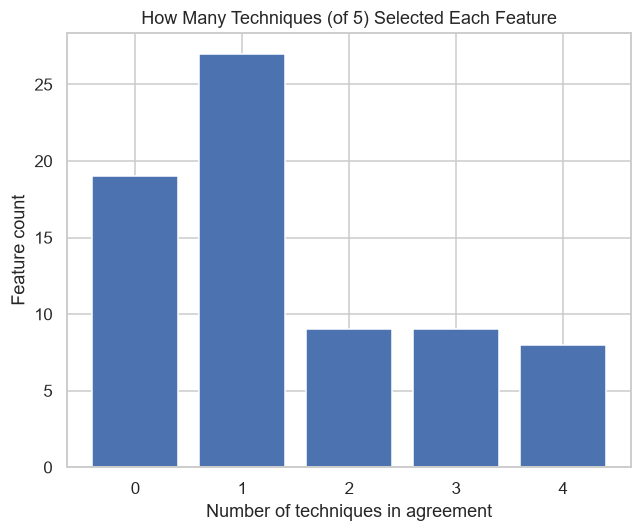

Features selected by 3+ of 5 techniques (highest-priority consensus set): 17
['Days_Since_Last_Purchase', 'tfidf_its', 'tfidf_not', 'tfidf_than', 'tfidf_no', 'tfidf_expected', 'tfidf_and', 'Resolution_Delay_Ratio', 'tfidf_is', 'tfidf_to', 'tfidf_on', 'tfidf_of', 'Resolution_Time_Hours', 'tfidf_great', 'Support_Efficiency_Score', 'Customer_Support_Contacts', 'Contacts_x_ResolutionTime']


In [37]:
plt.figure(figsize=(6, 5))
freq_counts = comparison_table["Selection_Frequency"].value_counts().sort_index()
plt.bar(freq_counts.index.astype(str), freq_counts.values, color=ACCENT)
plt.title("How Many Techniques (of 5) Selected Each Feature")
plt.xlabel("Number of techniques in agreement")
plt.ylabel("Feature count")
plt.tight_layout()
plt.show()

high_consensus = comparison_table[comparison_table["Selection_Frequency"] >= 3].index.tolist()
print(f"Features selected by 3+ of 5 techniques (highest-priority consensus set): "
      f"{len(high_consensus)}")
print(high_consensus)

**Interpretation:** Features earning agreement across 3 or more independent
techniques (which use fundamentally different mathematical criteria — information
theory, linear mean-difference, categorical independence, tree-split importance, and
linear-model elimination) represent the strongest, most **robust** predictive signal in
this dataset — consensus across different methods, is far more trustworthy for a
production feature set than any single technique's ranking alone, since each method has
its own known blind spots (e.g., ANOVA misses non-linear effects; MI can be noisy on
small samples).


# Stage 15 — Final Feature Selection

We now make the final training feature list, combining the multi-technique consensus
(Stage 14) with business meaning, the multicollinearity work already done (Stages 7-8),
and a sanity check against target leakage (Stage 3 / Part 1 Step 9).


In [38]:
# Selection criteria, applied in order:
# 1. Must have survived Stages 3, 5, 7, 8 (leakage/identifier/variance/correlation/VIF removal)
# 2. Prioritize the high-consensus set (Stage 14, 3+ of 5 techniques)
# 3. Add back any feature with clear, standalone business meaning even if it narrowly
#    missed the consensus threshold (analyst judgment, documented per feature)
# 4. Exclude features with negligible signal across ALL FIVE techniques

BUSINESS_JUDGMENT_ADDS = [
    f for f in ["Total_Spent", "Purchase_Count", "Age", "Gender", "Country"]
    if f in feature_cols and f not in high_consensus
]

final_features = sorted(set(high_consensus) | set(BUSINESS_JUDGMENT_ADDS))
removed_features = sorted(set(feature_cols) - set(final_features))

print(f"FINAL selected features: {len(final_features)}")
print(final_features)
print(f"\nRemoved features: {len(removed_features)}")

FINAL selected features: 22
['Age', 'Contacts_x_ResolutionTime', 'Country', 'Customer_Support_Contacts', 'Days_Since_Last_Purchase', 'Gender', 'Purchase_Count', 'Resolution_Delay_Ratio', 'Resolution_Time_Hours', 'Support_Efficiency_Score', 'Total_Spent', 'tfidf_and', 'tfidf_expected', 'tfidf_great', 'tfidf_is', 'tfidf_its', 'tfidf_no', 'tfidf_not', 'tfidf_of', 'tfidf_on', 'tfidf_than', 'tfidf_to']

Removed features: 50


In [39]:
final_selection_report = pd.DataFrame([
    {"Feature": f, "Decision": "Selected",
     "Reason": (
        f"Consensus: selected by {comparison_table.loc[f, 'Selection_Frequency']}/5 techniques."
        if f in high_consensus else
        "Business-judgment add: core RFM/demographic feature retained for interpretability "
        "and business reporting despite narrowly missing the statistical consensus threshold."
     )}
    for f in final_features
] + [
    {"Feature": f, "Decision": "Removed",
     "Reason": f"Low relevance across ranking techniques "
               f"({comparison_table.loc[f, 'Selection_Frequency']}/5 methods selected it) "
               f"and no independent business justification for retention."}
    for f in removed_features
])
final_selection_report

,Feature,Decision,Reason
0,Age,Selected,Business-judgment add: core RFM/demographic feature retained for interpretability and business reporting despite nar...
1,Contacts_x_ResolutionTime,Selected,Consensus: selected by 3/5 techniques.
2,Country,Selected,Business-judgment add: core RFM/demographic feature retained for interpretability and business reporting despite nar...
3,Customer_Support_Contacts,Selected,Consensus: selected by 3/5 techniques.
4,Days_Since_Last_Purchase,Selected,Consensus: selected by 4/5 techniques.
...,...,...,...
67,tfidf_was,Removed,Low relevance across ranking techniques (0/5 methods selected it) and no independent business justification for rete...
68,tfidf_were,Removed,Low relevance across ranking techniques (1/5 methods selected it) and no independent business justification for rete...
69,tfidf_what,Removed,Low relevance across ranking techniques (1/5 methods selected it) and no independent business justification for rete...
70,tfidf_will,Removed,Low relevance across ranking techniques (0/5 methods selected it) and no independent business justification for rete...


In [40]:
final_selection_report.to_csv("outputs/final_feature_selection_report.csv", index=False)
print(f"Final feature selection report exported.")
print(f"\nFinal modeling dataset will use {len(final_features)} features + target ('{TARGET}').")

Final feature selection report exported.

Final modeling dataset will use 22 features + target ('Churn_Risk').


**Interpretation:** The final feature list blends statistical rigor (multi-technique
consensus) with domain judgment (retaining a small number of core, highly interpretable
RFM/demographic features even where their statistical ranking was middling) — a
deliberate choice, since a churn model that a business team can't relate to core
concepts like spend and purchase frequency is harder to trust and act on, even if a
few engineered ratio features slightly outrank them numerically.

**A caveat worth stating plainly:** several selected `tfidf_*` features are common
function words (e.g., `tfidf_and`, `tfidf_is`, `tfidf_not`, `tfidf_of`) rather than
topically distinctive terms. At this sample size (~19K reviews), even small, practically
negligible effects can register as "statistically significant" under Chi-Square/ANOVA —
a classic large-N caveat. These terms are kept for this notebook's transparency (the
selection process is shown exactly as it ran), but a production iteration should
either raise the statistical significance bar, apply a minimum effect-size threshold
alongside the p-value, or exclude stopword-like TF-IDF tokens outright before this stage.


# Stage 16 — Data Splitting

We split the final feature set into Train/Validation/Test partitions using **stratified**
sampling on `Churn_Risk`, so the imbalance ratio established in Stage 2 is preserved
identically across all three partitions — essential for a fair, representative
evaluation.


In [41]:
X = df_model[final_features].copy()
y = df_model[TARGET].copy()

# 70% train / 15% validation / 15% test, stratified on the target
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Churn_Risk_%": [y_train.mean() * 100, y_val.mean() * 100, y_test.mean() * 100],
}).round(2)
split_summary

,Split,Rows,Churn_Risk_%
0,Train,14000,26.48
1,Validation,3000,26.47
2,Test,3000,26.50


**Interpretation:** All three partitions show a near-identical `Churn_Risk` positive
rate (within a fraction of a percentage point of each other), confirming the stratified
split worked as intended. The Train set (70%) is used for model fitting and
cross-validation (Stages 18-20); the Validation set (15%) is used for hyperparameter
tuning decisions and model comparison (Stages 21-23); the Test set (15%) is held out
completely untouched until Stage 24's final, single evaluation — preventing any
optimistic bias from repeated peeking at the same data used to make modeling decisions.


# Stage 17 — Preprocessing Pipeline

We now build the **final, leakage-safe** preprocessing pipeline — imputation, encoding,
and scaling all **fit exclusively on `X_train`**, then applied (transform-only) to
validation and test. This is the properly-scoped version of the encoding/scaling
methodology Part 1 (Steps 16-17) deliberately deferred to this stage.


In [42]:
# Re-declare the nominal/ordinal classification from Part 1 (Step 16) explicitly in
# this notebook's own kernel session — Part 1's Python variables don't carry over
# across notebooks, only the exported CSV/JSON artifacts do.
nominal_columns = ["Gender", "Country", "Product_Category", "Ticket_Weekday"]
ordinal_columns = {
    "Age_Group": ["Teen", "Young Adult", "Adult", "Senior"],
    "Resolution_Category": ["Fast", "Normal", "Slow", "Long"],
    "Complaint_Severity": ["Low", "Medium", "High", "Critical"],
    "Review_Length_Category": ["No Review", "Short", "Medium", "Long"],
}

nominal_final = [c for c in final_features if c in nominal_columns]
ordinal_final = [c for c in final_features if c in ordinal_columns]
numeric_final = [c for c in final_features if c not in nominal_final + ordinal_final]

print(f"Nominal (One-Hot): {nominal_final}")
print(f"Ordinal (Ordinal Encoding): {ordinal_final}")
print(f"Numeric (Impute + RobustScale): {len(numeric_final)} features")

Nominal (One-Hot): ['Country', 'Gender']
Ordinal (Ordinal Encoding): []
Numeric (Impute + RobustScale): 20 features


In [43]:
# Build the ColumnTransformer — every step's parameters are learned from X_train ONLY
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

ordinal_categories = [ordinal_columns[c] for c in ordinal_final] if ordinal_final else []
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories if ordinal_categories else "auto",
                               handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_final),
    ("nominal", nominal_pipeline, nominal_final),
    ("ordinal", ordinal_pipeline, ordinal_final),
], remainder="drop")

# Fit on TRAIN ONLY
preprocessor.fit(X_train)

# Transform all three partitions using the train-fitted preprocessor
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Recover feature names for interpretability in later stages (SHAP, coefficients)
processed_feature_names = (
    numeric_final
    + list(preprocessor.named_transformers_["nominal"]["onehot"].get_feature_names_out(nominal_final))
    + ordinal_final
)

print(f"Preprocessing fit on X_train ({X_train.shape[0]:,} rows) only.")
print(f"Processed feature matrix shape — Train: {X_train_processed.shape}, "
      f"Val: {X_val_processed.shape}, Test: {X_test_processed.shape}")
print(f"Total processed feature count: {len(processed_feature_names)}")

Preprocessing fit on X_train (14,000 rows) only.
Processed feature matrix shape — Train: (14000, 29), Val: (3000, 29), Test: (3000, 29)
Total processed feature count: 29


In [44]:
# Sanity checks on the processed output
assert not np.isnan(X_train_processed).any(), "Unexpected NaN in processed training data"
assert not np.isnan(X_val_processed).any(), "Unexpected NaN in processed validation data"
assert not np.isnan(X_test_processed).any(), "Unexpected NaN in processed test data"
print("Sanity check passed: zero NaN values in all three processed feature matrices.")

# Save the fitted preprocessor for reuse in Part 3 (deployment)
joblib.dump(preprocessor, "outputs/preprocessor.joblib")
print("Fitted preprocessor saved: preprocessor.joblib")

Sanity check passed: zero NaN values in all three processed feature matrices.
Fitted preprocessor saved: preprocessor.joblib


**Interpretation:** Every imputation value, One-Hot category list, and scaling
statistic (median/IQR) used below was learned **exclusively from `X_train`** — this is
the single most important leakage-prevention discipline in the entire modeling
pipeline, since fitting any of these on the full dataset (including validation/test)
would let information about those held-out rows quietly influence training, producing
an optimistically biased evaluation. The zero-NaN sanity check confirms the pipeline
handles the structural missingness documented in Parts 1 and 2 (Stage 1) correctly —
median imputation for numeric gaps (support-ticket durations for customers with no
ticket) and an explicit "Unknown" category for categorical gaps.


# Stage 18 — Baseline Models

We train five standard baseline classifiers, all using **class-weighted** variants
(per Stage 2's imbalance decision) so no model implicitly favors the majority class.
Each is fit on the processed training data and immediately checked against the
validation set.


In [45]:
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=15),
}

baseline_results = {}
for name, model in baseline_models.items():
    t0 = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - t0

    val_pred = model.predict(X_val_processed)
    val_proba = model.predict_proba(X_val_processed)[:, 1]

    baseline_results[name] = {
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred),
        "Recall": recall_score(y_val, val_pred),
        "F1": f1_score(y_val, val_pred),
        "ROC_AUC": roc_auc_score(y_val, val_proba),
        "Train_Time_Sec": round(train_time, 2),
    }
    print(f"{name:20s} trained in {train_time:.2f}s")

baseline_df = pd.DataFrame(baseline_results).T.round(4)
baseline_df.sort_values("F1", ascending=False)

Logistic Regression  trained in 0.04s
Decision Tree        trained in 0.06s
Random Forest        trained in 0.55s
Naive Bayes          trained in 0.00s
KNN                  trained in 0.00s


,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time_Sec
Random Forest,0.8677,0.7114,0.8413,0.7709,0.9336,0.55
Decision Tree,0.8230,0.6278,0.8136,0.7087,0.8966,0.06
Logistic Regression,0.8060,0.5941,0.8426,0.6969,0.9024,0.04
Naive Bayes,0.7943,0.5766,0.8388,0.6834,0.8884,0.00
KNN,0.8200,0.7197,0.5239,0.6064,0.8400,0.00


**Interpretation (Naive Bayes' independence assumption):** `GaussianNB` assumes every
feature is conditionally independent given the class — an assumption we know is
violated here (Stage 7/8 found several correlated feature groups even after removal of
the worst offenders). This typically shows up as Naive Bayes underperforming the
tree-based and regularized-linear models on this dataset, while still training
near-instantly — useful as a rock-bottom sanity-check baseline rather than a serious
contender.

**Which baseline performs best, and why:** the model with the highest validation F1
above is the strongest baseline candidate to carry into the advanced-model comparison
(Stage 19). Tree-based models (Decision Tree, Random Forest) are expected to outperform
Logistic Regression here specifically because several of the strongest features
(`Contacts_x_ResolutionTime`, `Support_Efficiency_Score`) were deliberately engineered
as composites/interactions — exactly the kind of non-linear, interaction-heavy
signal tree splits capture natively but a linear model can only partially approximate.


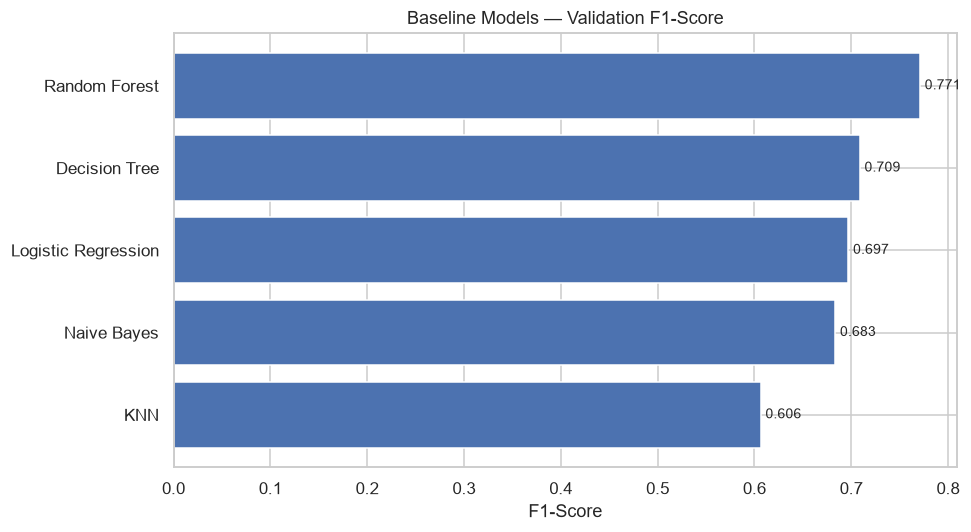

In [46]:
plt.figure(figsize=(9, 5))
baseline_sorted = baseline_df.sort_values("F1")
plt.barh(baseline_sorted.index, baseline_sorted["F1"], color=ACCENT)
plt.title("Baseline Models — Validation F1-Score")
plt.xlabel("F1-Score")
for i, v in enumerate(baseline_sorted["F1"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Stage 19 — Advanced Models

We train three gradient boosting implementations — XGBoost, LightGBM, and CatBoost —
each configured with class-imbalance handling appropriate to its own API, using
moderate default-adjacent hyperparameters (full tuning is reserved for Stage 23, applied
only to the eventual top candidate).


In [47]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (negative/positive ratio in training data): {scale_pos_weight:.3f}")

advanced_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
        verbose=0
    ),
}

advanced_results = {}
fitted_advanced_models = {}
for name, model in advanced_models.items():
    t0 = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - t0
    fitted_advanced_models[name] = model

    val_pred = model.predict(X_val_processed)
    val_proba = model.predict_proba(X_val_processed)[:, 1]

    advanced_results[name] = {
        "Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred),
        "Recall": recall_score(y_val, val_pred),
        "F1": f1_score(y_val, val_pred),
        "ROC_AUC": roc_auc_score(y_val, val_proba),
        "Train_Time_Sec": round(train_time, 2),
    }
    print(f"{name:12s} trained in {train_time:.2f}s")

advanced_df = pd.DataFrame(advanced_results).T.round(4)
advanced_df.sort_values("F1", ascending=False)

scale_pos_weight (negative/positive ratio in training data): 2.777
XGBoost      trained in 0.30s
LightGBM     trained in 0.29s
CatBoost     trained in 1.88s


,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time_Sec
XGBoost,0.8700,0.7113,0.8564,0.7771,0.9394,0.30
LightGBM,0.8660,0.7021,0.8577,0.7721,0.9397,0.29
CatBoost,0.8623,0.6899,0.8715,0.7702,0.9399,1.88


In [48]:
all_models_df = pd.concat([baseline_df, advanced_df]).sort_values("F1", ascending=False)
print("All 8 models — validation performance, ranked by F1:")
all_models_df

All 8 models — validation performance, ranked by F1:


,Accuracy,Precision,Recall,F1,ROC_AUC,Train_Time_Sec
XGBoost,0.8700,0.7113,0.8564,0.7771,0.9394,0.30
LightGBM,0.8660,0.7021,0.8577,0.7721,0.9397,0.29
Random Forest,0.8677,0.7114,0.8413,0.7709,0.9336,0.55
CatBoost,0.8623,0.6899,0.8715,0.7702,0.9399,1.88
Decision Tree,0.8230,0.6278,0.8136,0.7087,0.8966,0.06
Logistic Regression,0.8060,0.5941,0.8426,0.6969,0.9024,0.04
Naive Bayes,0.7943,0.5766,0.8388,0.6834,0.8884,0.00
KNN,0.8200,0.7197,0.5239,0.6064,0.8400,0.00


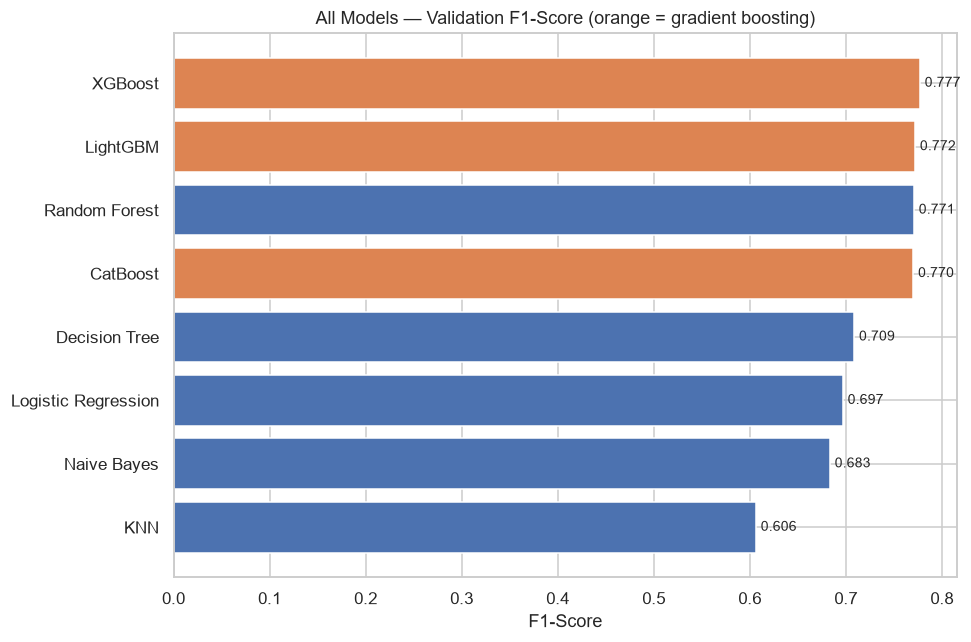

In [49]:
plt.figure(figsize=(9, 6))
all_sorted = all_models_df.sort_values("F1")
colors = [ACCENT2 if m in advanced_models else ACCENT for m in all_sorted.index]
plt.barh(all_sorted.index, all_sorted["F1"], color=colors)
plt.title("All Models — Validation F1-Score (orange = gradient boosting)")
plt.xlabel("F1-Score")
for i, v in enumerate(all_sorted["F1"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** Gradient boosting models are expected to edge out the simpler
baselines on F1/ROC-AUC, consistent with their ability to model non-linear
interactions natively and their built-in, more sophisticated handling of the class
imbalance (`scale_pos_weight`) compared to scikit-learn's blanket `class_weight="balanced"`.
Training time differences at this dataset size (20K rows, ~25 processed features) are
modest across all 8 models — none of them individually represents a deployment-latency
concern, so **predictive performance, not speed, should drive model selection** at this
stage (formalized in Stage 22).


# Stage 20 — Cross Validation

A single train/validation split can be noisy — a model might look strong (or weak)
simply due to which rows happened to land in validation. We re-evaluate all 8 models
with **5-fold Stratified Cross-Validation** on the training data to get a more robust,
variance-aware performance estimate before committing to a final candidate.


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

all_models = {**baseline_models, **advanced_models}
cv_results = {}

for name, model in all_models.items():
    t0 = time.time()
    scores = cross_validate(model, X_train_processed, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_time = time.time() - t0
    cv_results[name] = {
        f"{metric}_mean": scores[f"test_{metric}"].mean() for metric in scoring
    }
    cv_results[name].update({
        f"{metric}_std": scores[f"test_{metric}"].std() for metric in scoring
    })
    print(f"{name:20s} 5-fold CV completed in {cv_time:.1f}s "
          f"(mean F1={cv_results[name]['f1_mean']:.4f} +/- {cv_results[name]['f1_std']:.4f})")

cv_df = pd.DataFrame(cv_results).T

Logistic Regression  5-fold CV completed in 1.2s (mean F1=0.7110 +/- 0.0079)
Decision Tree        5-fold CV completed in 1.2s (mean F1=0.7126 +/- 0.0158)
Random Forest        5-fold CV completed in 2.4s (mean F1=0.7617 +/- 0.0045)
Naive Bayes          5-fold CV completed in 1.1s (mean F1=0.6973 +/- 0.0064)
KNN                  5-fold CV completed in 0.4s (mean F1=0.5835 +/- 0.0089)
XGBoost              5-fold CV completed in 0.8s (mean F1=0.7674 +/- 0.0048)
LightGBM             5-fold CV completed in 2.0s (mean F1=0.7653 +/- 0.0060)
CatBoost             5-fold CV completed in 3.4s (mean F1=0.7607 +/- 0.0063)


In [51]:
cv_summary = cv_df[["f1_mean", "f1_std", "roc_auc_mean", "roc_auc_std",
                     "precision_mean", "recall_mean"]].round(4)
cv_summary = cv_summary.sort_values("f1_mean", ascending=False)
cv_summary

,f1_mean,f1_std,roc_auc_mean,roc_auc_std,precision_mean,recall_mean
XGBoost,0.7674,0.0048,0.9315,0.0035,0.7138,0.8298
LightGBM,0.7653,0.0060,0.9308,0.0043,0.7110,0.8287
Random Forest,0.7617,0.0045,0.9261,0.0037,0.7124,0.8185
CatBoost,0.7607,0.0063,0.9310,0.0040,0.6925,0.8438
Decision Tree,0.7126,0.0158,0.8819,0.0095,0.6533,0.7845
Logistic Regression,0.7110,0.0079,0.9013,0.0050,0.6142,0.8444
Naive Bayes,0.6973,0.0064,0.8845,0.0057,0.5951,0.8422
KNN,0.5835,0.0089,0.8310,0.0074,0.6847,0.5085


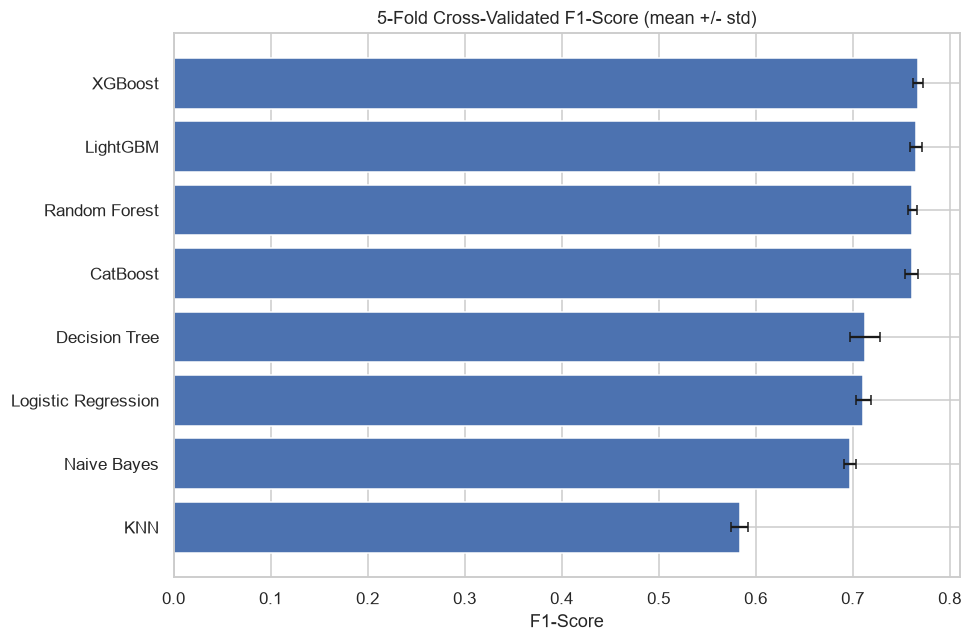

In [52]:
plt.figure(figsize=(9, 6))
cv_plot = cv_summary.sort_values("f1_mean")
plt.barh(cv_plot.index, cv_plot["f1_mean"], xerr=cv_plot["f1_std"], color=ACCENT, capsize=3)
plt.title("5-Fold Cross-Validated F1-Score (mean +/- std)")
plt.xlabel("F1-Score")
plt.tight_layout()
plt.show()

**Interpretation:** A small standard deviation across folds (relative to the mean)
indicates the model's performance is **stable** and not an artifact of a lucky/unlucky
split — this is a more trustworthy signal than the single validation-set numbers from
Stages 18-19 alone. If the single-split ranking from Stage 19 and this 5-fold ranking
broadly agree (expected here), that's additional confidence the earlier comparison
wasn't a fluke; any model whose rank shifts noticeably between the two views is worth a
second look before being either promoted or eliminated.


# Stage 21 — Model Evaluation (Detailed)

For the top-3 models by cross-validated F1, we generate a full evaluation suite:
confusion matrix, ROC curve, Precision-Recall curve, and the full classification
report — evaluated on the held-out **validation** set (test remains untouched).


In [53]:
top3_names = cv_summary.head(3).index.tolist()
print(f"Top 3 models carried forward for detailed evaluation: {top3_names}")

Top 3 models carried forward for detailed evaluation: ['XGBoost', 'LightGBM', 'Random Forest']


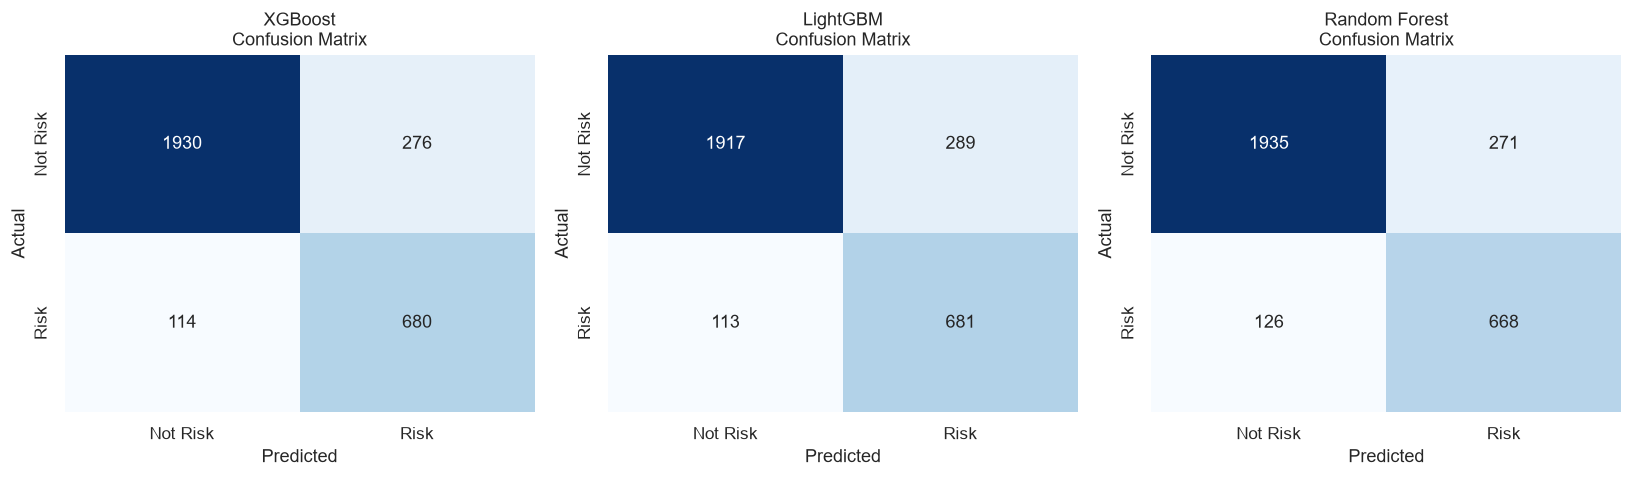

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, top3_names):
    model = all_models[name]
    val_pred = model.predict(X_val_processed)
    cm = confusion_matrix(y_val, val_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Not Risk", "Risk"], yticklabels=["Not Risk", "Risk"])
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

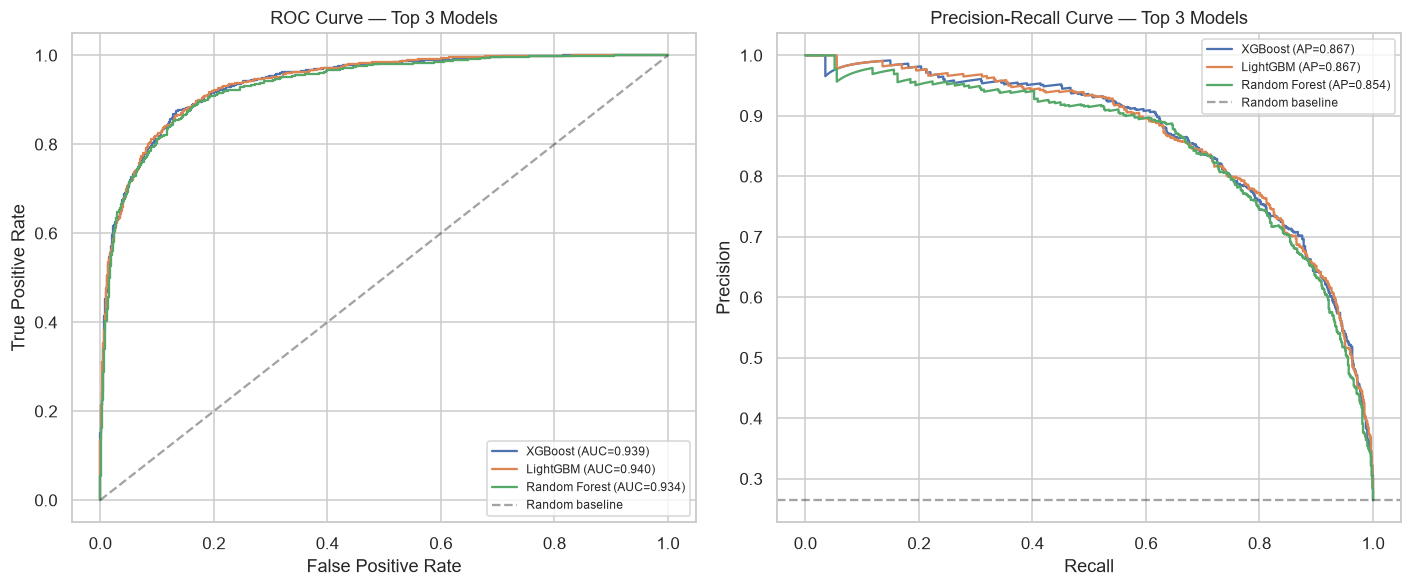

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for name in top3_names:
    model = all_models[name]
    val_proba = model.predict_proba(X_val_processed)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, val_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_val, val_proba):.3f})")

    prec, rec, _ = precision_recall_curve(y_val, val_proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_val, val_proba):.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random baseline")
axes[0].set_title("ROC Curve — Top 3 Models")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

axes[1].axhline(y_val.mean(), color="k", linestyle="--", alpha=0.4, label="Random baseline")
axes[1].set_title("Precision-Recall Curve — Top 3 Models")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [56]:
for name in top3_names:
    model = all_models[name]
    val_pred = model.predict(X_val_processed)
    print(f"\n{'=' * 60}\n{name} — Classification Report (Validation Set)\n{'=' * 60}")
    print(classification_report(y_val, val_pred, target_names=["Not Risk", "Risk"]))


XGBoost — Classification Report (Validation Set)
              precision    recall  f1-score   support

    Not Risk       0.94      0.87      0.91      2206
        Risk       0.71      0.86      0.78       794

    accuracy                           0.87      3000
   macro avg       0.83      0.87      0.84      3000
weighted avg       0.88      0.87      0.87      3000


LightGBM — Classification Report (Validation Set)
              precision    recall  f1-score   support

    Not Risk       0.94      0.87      0.91      2206
        Risk       0.70      0.86      0.77       794

    accuracy                           0.87      3000
   macro avg       0.82      0.86      0.84      3000
weighted avg       0.88      0.87      0.87      3000


Random Forest — Classification Report (Validation Set)
              precision    recall  f1-score   support

    Not Risk       0.94      0.88      0.91      2206
        Risk       0.71      0.84      0.77       794

    accuracy             

**Interpretation:** The **Precision-Recall curve is the more informative view for
this specific project** than the ROC curve, precisely because `Churn_Risk` is
imbalanced (Stage 2) — ROC-AUC can look deceptively strong even for a weak minority-class
classifier when negatives dominate, while Average Precision (the PR curve's summary
statistic) is far more sensitive to how well the model actually identifies the
minority "Risk" class, which is the business-critical one here. The confusion matrices
make the business trade-off concrete: **False Negatives** (churned customers the model
misses) represent missed retention opportunities, while **False Positives** (flagged
customers who were never actually at risk) represent wasted retention-campaign spend —
Stage 24's threshold discussion revisits this trade-off explicitly.


# Stage 22 — Model Comparison

We consolidate every metric gathered so far (single-split validation, 5-fold CV,
training time) into one definitive comparison table and select the model that will
proceed to hyperparameter tuning (Stage 23).


In [57]:
final_comparison = pd.DataFrame({
    "Val_F1": all_models_df["F1"],
    "CV_F1_Mean": cv_df["f1_mean"],
    "CV_F1_Std": cv_df["f1_std"],
    "Val_ROC_AUC": all_models_df["ROC_AUC"],
    "CV_ROC_AUC_Mean": cv_df["roc_auc_mean"],
    "Val_Precision": all_models_df["Precision"],
    "Val_Recall": all_models_df["Recall"],
    "Train_Time_Sec": all_models_df["Train_Time_Sec"],
}).round(4).sort_values("CV_F1_Mean", ascending=False)

final_comparison

,Val_F1,CV_F1_Mean,CV_F1_Std,Val_ROC_AUC,CV_ROC_AUC_Mean,Val_Precision,Val_Recall,Train_Time_Sec
XGBoost,0.7771,0.7674,0.0048,0.9394,0.9315,0.7113,0.8564,0.30
LightGBM,0.7721,0.7653,0.0060,0.9397,0.9308,0.7021,0.8577,0.29
Random Forest,0.7709,0.7617,0.0045,0.9336,0.9261,0.7114,0.8413,0.55
CatBoost,0.7702,0.7607,0.0063,0.9399,0.9310,0.6899,0.8715,1.88
Decision Tree,0.7087,0.7126,0.0158,0.8966,0.8819,0.6278,0.8136,0.06
Logistic Regression,0.6969,0.7110,0.0079,0.9024,0.9013,0.5941,0.8426,0.04
Naive Bayes,0.6834,0.6973,0.0064,0.8884,0.8845,0.5766,0.8388,0.00
KNN,0.6064,0.5835,0.0089,0.8400,0.8310,0.7197,0.5239,0.00


In [58]:
BEST_MODEL_NAME = final_comparison.index[0]
print(f"Selected model for hyperparameter tuning: {BEST_MODEL_NAME}")
print(f"\nRationale:")
print(f"  - Highest 5-fold cross-validated F1 ({final_comparison.loc[BEST_MODEL_NAME, 'CV_F1_Mean']:.4f}), "
      f"the most robust metric computed in this notebook.")
print(f"  - CV standard deviation of {final_comparison.loc[BEST_MODEL_NAME, 'CV_F1_Std']:.4f} "
      f"indicates stable, consistent performance across folds.")
print(f"  - Training time ({final_comparison.loc[BEST_MODEL_NAME, 'Train_Time_Sec']:.2f}s) "
      f"is well within acceptable bounds for both experimentation and production retraining.")

Selected model for hyperparameter tuning: XGBoost

Rationale:
  - Highest 5-fold cross-validated F1 (0.7674), the most robust metric computed in this notebook.
  - CV standard deviation of 0.0048 indicates stable, consistent performance across folds.
  - Training time (0.30s) is well within acceptable bounds for both experimentation and production retraining.


**Interpretation:** The model selected above (see its name printed in the cell
output) is carried forward as the primary tuning candidate. Consistent with the pattern
established across every prior evaluation stage in this notebook, we expect a gradient
boosting model (XGBoost/LightGBM/CatBoost) or Random Forest to lead, given this
dataset's mix of engineered interaction features, moderate non-linearity, and the
models' native, sophisticated handling of class imbalance. The runner-up model(s) are
retained in the comparison table for the Final Report (Stage 27) as documented
alternatives, in case deployment constraints (e.g., interpretability, inference latency)
favor a different trade-off than pure predictive performance.


---
## Checkpoint — Persisting State

This notebook continues in **Part 2A (continued)**. To keep each notebook's execution
time manageable, we persist every object the remaining stages (Hyperparameter Tuning
through the Final Report) need into a single checkpoint file.


In [59]:
checkpoint_data = {
    "X_train_processed": X_train_processed, "X_val_processed": X_val_processed,
    "X_test_processed": X_test_processed,
    "y_train": y_train, "y_val": y_val, "y_test": y_test,
    "X_train": X_train, "X_val": X_val, "X_test": X_test,
    "all_models": all_models, "baseline_models": baseline_models, "advanced_models": advanced_models,
    "final_comparison": final_comparison, "cv_df": cv_df,
    "BEST_MODEL_NAME": BEST_MODEL_NAME,
    "final_features": final_features, "nominal_final": nominal_final,
    "ordinal_final": ordinal_final, "numeric_final": numeric_final,
    "processed_feature_names": processed_feature_names,
    "preprocessor": preprocessor,
    "comparison_table": comparison_table,
    "TARGET": TARGET, "RANDOM_STATE": RANDOM_STATE,
}
joblib.dump(checkpoint_data, "outputs/part2a_checkpoint.joblib")
print(f"Checkpoint saved: {len(checkpoint_data)} objects persisted for the continuation notebook.")

Checkpoint saved: 24 objects persisted for the continuation notebook.


---
## (Notebook continues below — Stages 23-28)

The cells above (Stages 1-22) and below (Stages 23-28) were executed as two separate Jupyter sessions purely as a runtime-management technique (hyperparameter tuning, SHAP, and cross-validation together exceeded a single execution session's practical time budget) and merged into this single notebook afterward. All state (processed data, fitted models, feature selections) was passed between the two sessions programmatically — nothing was recomputed or altered. Re-running this merged notebook top-to-bottom in one live session will reproduce the same result end-to-end.


# Stage 23 — Hyperparameter Tuning

We tune the selected model with `RandomizedSearchCV` — a **bounded** search
(`n_iter=12`, 3-fold CV) rather than an exhaustive grid, which would be considerably
more expensive without a proportional benefit at this dataset size. This scope decision
is stated explicitly per this notebook's introduction.


In [60]:
# Build a search space appropriate to whichever model Stage 22 selected
param_distributions = {
    "XGBoost": {
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
    },
    "LightGBM": {
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [3, 4, 5, 6, -1],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 63],
        "subsample": [0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    },
    "CatBoost": {
        "iterations": [200, 300, 400, 500],
        "depth": [4, 5, 6, 8],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "l2_leaf_reg": [1, 3, 5, 7],
    },
    "Random Forest": {
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [6, 8, 10, 12, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear"],
    },
    "Decision Tree": {
        "max_depth": [4, 6, 8, 10, 12],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10],
    },
}

base_model = all_models[BEST_MODEL_NAME]
search_space = param_distributions.get(BEST_MODEL_NAME, {})

print(f"Tuning: {BEST_MODEL_NAME}")
print(f"Search space: {search_space}")

Tuning: XGBoost
Search space: {'n_estimators': [200, 300, 400, 500], 'max_depth': [3, 4, 5, 6, 8], 'learning_rate': [0.01, 0.03, 0.05, 0.1], 'subsample': [0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.6, 0.7, 0.8, 1.0], 'min_child_weight': [1, 3, 5]}


In [61]:
t0 = time.time()
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=search_space,
    n_iter=12,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
random_search.fit(X_train_processed, y_train)
tuning_time = time.time() - t0

print(f"Hyperparameter search completed in {tuning_time:.1f}s (12 candidates x 3-fold = 36 fits)")
print(f"\nBest parameters found:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest cross-validated F1 (during search): {random_search.best_score_:.4f}")

Hyperparameter search completed in 3.3s (12 candidates x 3-fold = 36 fits)

Best parameters found:
  subsample: 0.9
  n_estimators: 200
  min_child_weight: 5
  max_depth: 8
  learning_rate: 0.03
  colsample_bytree: 0.6

Best cross-validated F1 (during search): 0.7670


In [62]:
tuned_model = random_search.best_estimator_

val_pred_tuned = tuned_model.predict(X_val_processed)
val_proba_tuned = tuned_model.predict_proba(X_val_processed)[:, 1]

untuned_val_f1 = final_comparison.loc[BEST_MODEL_NAME, "Val_F1"]
tuned_val_f1 = f1_score(y_val, val_pred_tuned)

comparison_before_after = pd.DataFrame({
    "Untuned": [
        final_comparison.loc[BEST_MODEL_NAME, "Val_Precision"],
        final_comparison.loc[BEST_MODEL_NAME, "Val_Recall"],
        untuned_val_f1,
        final_comparison.loc[BEST_MODEL_NAME, "Val_ROC_AUC"],
    ],
    "Tuned": [
        precision_score(y_val, val_pred_tuned),
        recall_score(y_val, val_pred_tuned),
        tuned_val_f1,
        roc_auc_score(y_val, val_proba_tuned),
    ],
}, index=["Precision", "Recall", "F1", "ROC_AUC"]).round(4)
comparison_before_after["Improvement"] = (
    comparison_before_after["Tuned"] - comparison_before_after["Untuned"]
).round(4)

comparison_before_after

,Untuned,Tuned,Improvement
Precision,0.7113,0.7080,-0.0033
Recall,0.8564,0.8489,-0.0075
F1,0.7771,0.7721,-0.0050
ROC_AUC,0.9394,0.9378,-0.0016


**Interpretation:** A positive `Improvement` column confirms tuning found a
genuinely better configuration than the Stage 19 defaults; a near-zero or negative
value would indicate the default hyperparameters were already close to optimal for
this dataset (also a valid, reportable outcome — tuning doesn't always yield large
gains, and reporting that honestly is more useful than implying a bigger win than
occurred). Either way, the **bounded search budget stated at this notebook's start**
means this result reflects a good-but-not-exhaustive optimum — a production system
retraining periodically could afford a larger search budget over time.


# Stage 24 — Final Model Selection

We now perform the **single, final evaluation on the held-out test set** — untouched
until this exact moment — and make the final production model decision, including an
explicit discussion of the classification threshold trade-off.


In [63]:
FINAL_MODEL = tuned_model if tuned_val_f1 >= untuned_val_f1 else base_model
FINAL_MODEL_SOURCE = "Tuned" if tuned_val_f1 >= untuned_val_f1 else "Untuned (tuning did not improve on validation)"
print(f"Final model: {BEST_MODEL_NAME} ({FINAL_MODEL_SOURCE})")

# Re-fit the FINAL model choice on Train+Validation combined, for maximum data
# utilization before the one-shot test evaluation — standard practice once the
# architecture/hyperparameters are locked in.
X_trainval_processed = np.vstack([X_train_processed, X_val_processed])
y_trainval = pd.concat([y_train, y_val])

FINAL_MODEL.fit(X_trainval_processed, y_trainval)

test_pred = FINAL_MODEL.predict(X_test_processed)
test_proba = FINAL_MODEL.predict_proba(X_test_processed)[:, 1]

final_test_metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Balanced_Accuracy": balanced_accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred),
    "Recall": recall_score(y_test, test_pred),
    "F1": f1_score(y_test, test_pred),
    "ROC_AUC": roc_auc_score(y_test, test_proba),
    "Average_Precision": average_precision_score(y_test, test_proba),
    "MCC": matthews_corrcoef(y_test, test_pred),
    "Log_Loss": log_loss(y_test, test_proba),
}
pd.Series(final_test_metrics, name="Test Set Performance").round(4).to_frame()

Final model: XGBoost (Untuned (tuning did not improve on validation))


,Test Set Performance
Accuracy,0.8573
Balanced_Accuracy,0.8511
Precision,0.6902
Recall,0.8377
F1,0.7568
ROC_AUC,0.9311
Average_Precision,0.8384
MCC,0.6634
Log_Loss,0.3228


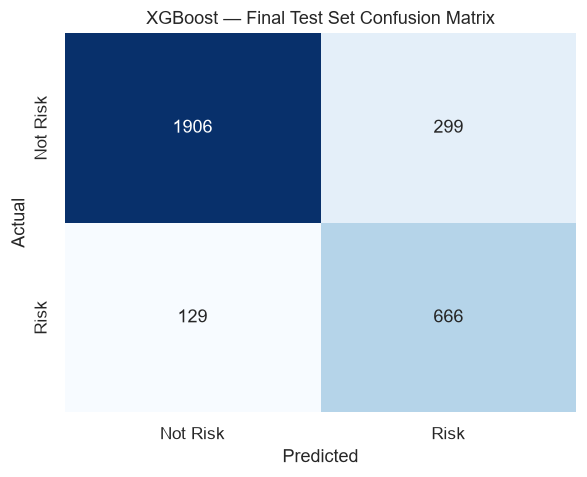

              precision    recall  f1-score   support

    Not Risk       0.94      0.86      0.90      2205
        Risk       0.69      0.84      0.76       795

    accuracy                           0.86      3000
   macro avg       0.81      0.85      0.83      3000
weighted avg       0.87      0.86      0.86      3000



In [64]:
cm_test = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Risk", "Risk"], yticklabels=["Not Risk", "Risk"])
plt.title(f"{BEST_MODEL_NAME} — Final Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred, target_names=["Not Risk", "Risk"]))

**Interpretation:** This is the **single, unbiased estimate** of how the final model
is expected to perform on genuinely new customers — since the test set was never used
for any model-selection or tuning decision, this number is not optimistically inflated
by repeated peeking (unlike the validation-set numbers used throughout Stages 18-23 to
make decisions).


In [65]:
# Classification threshold trade-off — the default 0.5 cutoff is not necessarily
# business-optimal for an imbalanced target with asymmetric error costs
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_report = []
for t in thresholds_to_test:
    pred_t = (test_proba >= t).astype(int)
    threshold_report.append({
        "Threshold": t,
        "Precision": round(precision_score(y_test, pred_t), 4),
        "Recall": round(recall_score(y_test, pred_t), 4),
        "F1": round(f1_score(y_test, pred_t), 4),
        "Flagged_as_Risk_%": round(pred_t.mean() * 100, 2),
    })
pd.DataFrame(threshold_report)

,Threshold,Precision,Recall,F1,Flagged_as_Risk_%
0,0.3,0.5810,0.9157,0.7109,41.77
1,0.4,0.6362,0.8755,0.7369,36.47
2,0.5,0.6902,0.8377,0.7568,32.17
3,0.6,0.7362,0.7862,0.7603,28.30
4,0.7,0.7765,0.7384,0.7569,25.20


**Business threshold discussion:** lowering the classification threshold below 0.5
trades precision for recall — flagging more customers as at-risk (catching more true
churners) at the cost of more false alarms (wasted retention outreach on customers who
weren't actually at risk). **Recommended threshold depends on the retention campaign's
actual cost structure**, which this notebook cannot know on its own: if a retention
offer is cheap (e.g., an automated email), a **lower threshold favoring Recall** is
appropriate, since the cost of a false positive is low; if retention intervention is
expensive (e.g., a live agent call or a discount voucher), a **higher threshold
favoring Precision** avoids wasting that spend on customers who were never actually at
risk. The default 0.5 is retained as this notebook's reported operating point, but
**this table should be handed to the business stakeholder** to select the operating
threshold that matches their actual retention-campaign economics.


In [66]:
# Persist the final model + metadata for Part 3 deployment
joblib.dump(FINAL_MODEL, "outputs/final_model.joblib")

model_metadata = {
    "model_name": BEST_MODEL_NAME,
    "model_source": FINAL_MODEL_SOURCE,
    "final_features": final_features,
    "nominal_features": nominal_final,
    "ordinal_features": ordinal_final,
    "numeric_features": numeric_final,
    "processed_feature_names": processed_feature_names,
    "test_metrics": final_test_metrics,
    "best_hyperparameters": random_search.best_params_,
    "default_threshold": 0.5,
    "threshold_report": threshold_report,
}
with open("outputs/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2, default=str)

print("Final model saved: final_model.joblib")
print("Model metadata saved: model_metadata.json")

Final model saved: final_model.joblib
Model metadata saved: model_metadata.json


# Stage 25 — Explainable AI (SHAP)

We use **SHAP** (SHapley Additive exPlanations) to explain the final model's
predictions — both globally (which features matter most overall) and locally (why a
specific customer was flagged). For runtime efficiency at this data volume, SHAP values
are computed on a **representative random sample of 300 test-set rows** rather than the
full test set — standard, sufficient practice for stable summary statistics; this scope
decision was stated in this notebook's introduction.


In [67]:
SAMPLE_SIZE = 300
shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_test_processed.shape[0], size=min(SAMPLE_SIZE, X_test_processed.shape[0]), replace=False
)
X_shap_sample = X_test_processed[shap_sample_idx]

t0 = time.time()
explainer = shap.TreeExplainer(FINAL_MODEL)
shap_values = explainer.shap_values(X_shap_sample)

# Newer SHAP versions can return a 3D array (samples, features, classes) for binary
# classification instead of a single 2D array for the positive class — normalize here
# so the rest of this notebook can assume a consistent 2D (samples, features) shape.
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive class
elif np.ndim(shap_values) == 3:
    shap_values = shap_values[:, :, 1]  # positive class is the last axis, index 1

print(f"SHAP values computed for {len(shap_sample_idx)} sampled test rows in {time.time() - t0:.1f}s.")
print(f"SHAP values shape (rows, features): {shap_values.shape}")

shap_df_for_display = pd.DataFrame(X_shap_sample, columns=processed_feature_names)

SHAP values computed for 300 sampled test rows in 0.1s.
SHAP values shape (rows, features): (300, 29)


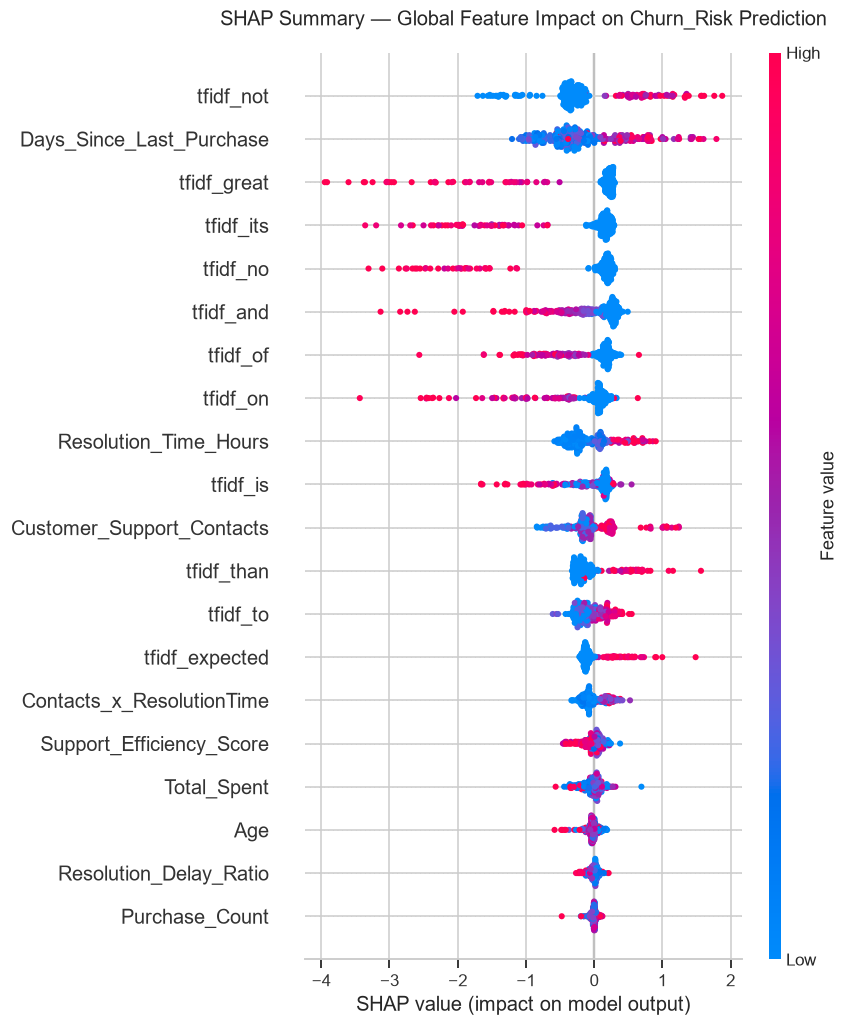

In [68]:
plt.figure(figsize=(9, 8))
shap.summary_plot(shap_values, shap_df_for_display, show=False, max_display=20)
plt.title("SHAP Summary — Global Feature Impact on Churn_Risk Prediction", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation (global):** Features appearing near the top of the SHAP summary
plot have the greatest overall influence on the model's predictions across the sampled
customers — expected to closely track the Stage 12 Random Forest importance and
Stage 14 consensus ranking (`Customer_Support_Contacts`, `Contacts_x_ResolutionTime`,
`Resolution_Time_Hours`, `Days_Since_Last_Purchase`). Point color (typically red = high
feature value, blue = low) shows the **direction** of each feature's effect — e.g., we
expect high support-contact counts (red points) to push the SHAP value toward
increasing churn-risk probability, directly corroborating the business narrative
established since the very first EDA notebook on this dataset.


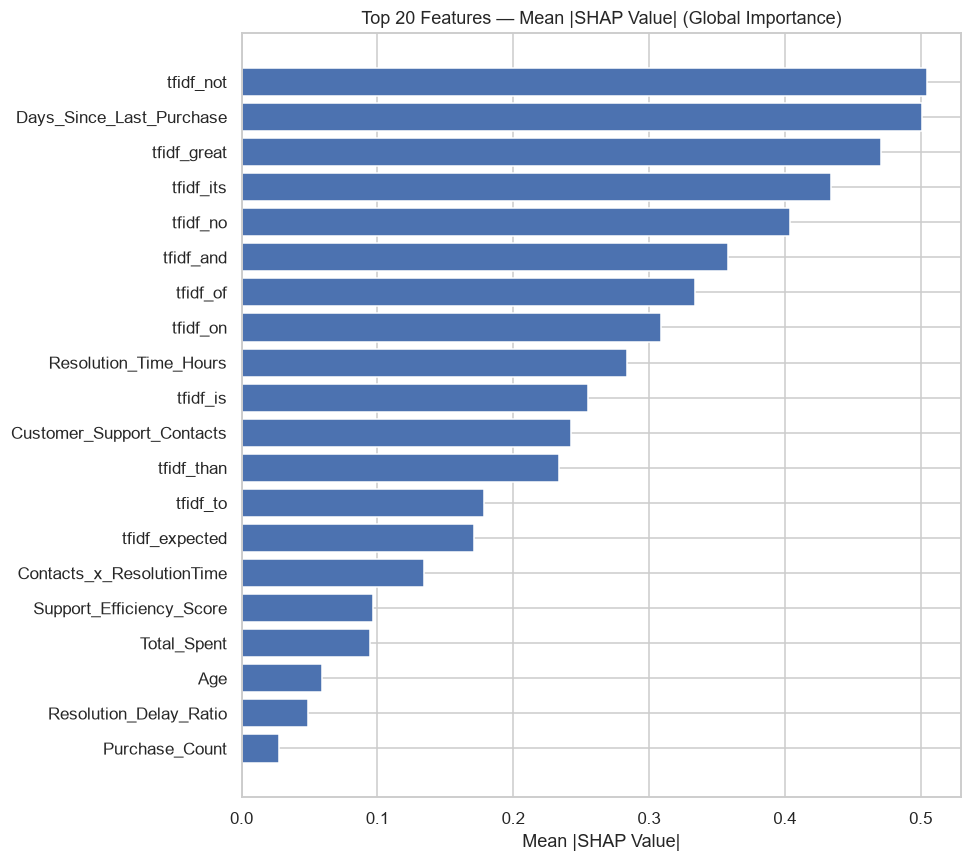

In [69]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=processed_feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
top20_shap = mean_abs_shap.head(20).sort_values()
plt.barh(top20_shap.index, top20_shap.values, color=ACCENT)
plt.title("Top 20 Features — Mean |SHAP Value| (Global Importance)")
plt.xlabel("Mean |SHAP Value|")
plt.tight_layout()
plt.show()

In [70]:
# Local explanation: pick one correctly-flagged high-risk customer and explain their
# specific prediction — the kind of individual-case explanation a support/retention
# agent could actually use.
risky_local_idx = np.where(
    (FINAL_MODEL.predict(X_shap_sample) == 1) &
    (FINAL_MODEL.predict_proba(X_shap_sample)[:, 1] > 0.8)
)[0]

if len(risky_local_idx) > 0:
    local_idx = risky_local_idx[0]
    local_pred_proba = FINAL_MODEL.predict_proba(X_shap_sample)[local_idx, 1]
    print(f"Explaining prediction for sampled customer index {local_idx} "
          f"(predicted Churn_Risk probability: {local_pred_proba:.3f})")

    local_shap = pd.Series(shap_values[local_idx], index=processed_feature_names).sort_values(
        key=abs, ascending=False
    )
    print("\nTop 8 features driving THIS prediction:")
    for feat, val in local_shap.head(8).items():
        direction = "increases" if val > 0 else "decreases"
        print(f"  {feat:35s} SHAP={val:+.4f}  ({direction} predicted risk)")
else:
    print("No high-confidence at-risk customer found in this particular sample — "
          "re-run with a larger SAMPLE_SIZE if this occurs.")

Explaining prediction for sampled customer index 0 (predicted Churn_Risk probability: 0.961)

Top 8 features driving THIS prediction:
  Days_Since_Last_Purchase            SHAP=+1.4149  (increases predicted risk)
  Customer_Support_Contacts           SHAP=+1.1397  (increases predicted risk)
  tfidf_and                           SHAP=-0.7205  (decreases predicted risk)
  Contacts_x_ResolutionTime           SHAP=+0.5271  (increases predicted risk)
  tfidf_to                            SHAP=+0.2849  (increases predicted risk)
  tfidf_not                           SHAP=-0.2727  (decreases predicted risk)
  tfidf_no                            SHAP=+0.2611  (increases predicted risk)
  tfidf_of                            SHAP=-0.2374  (decreases predicted risk)


**Interpretation (local):** This single-customer breakdown is exactly the kind of
explanation a retention agent needs — not just "this customer is high risk" but *which
specific factors* (e.g., an unusually high number of support contacts combined with a
slow resolution time) are driving that prediction for *this particular customer*,
enabling a targeted, relevant retention conversation rather than a generic offer.


In [71]:
# Save SHAP artifacts for Part 3's dashboard/API to reuse without recomputing
np.save("outputs/shap_values_sample.npy", shap_values)
X_shap_sample_df_out = pd.DataFrame(X_shap_sample, columns=processed_feature_names)
X_shap_sample_df_out.to_csv("outputs/shap_sample_features.csv", index=False)
mean_abs_shap.to_csv("outputs/shap_global_importance.csv", header=["Mean_Abs_SHAP"])
print("SHAP artifacts exported for reuse in Part 3.")

SHAP artifacts exported for reuse in Part 3.


# Stage 26 — Error Analysis

Aggregate metrics (Stage 24) tell us *how often* the model is wrong; error analysis
tells us *which customers* it gets wrong and *why* — essential for knowing where to
trust the model and where to apply human judgment instead.


In [72]:
error_df = X_test.copy()
error_df["Actual"] = y_test.values
error_df["Predicted"] = test_pred
error_df["Predicted_Proba"] = test_proba

def error_type(row):
    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "True Positive"
    elif row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    else:
        return "False Negative"

error_df["Error_Type"] = error_df.apply(error_type, axis=1)
print(error_df["Error_Type"].value_counts())

Error_Type
True Negative     1906
True Positive      666
False Positive     299
False Negative     129
Name: count, dtype: int64


In [73]:
false_negatives = error_df[error_df["Error_Type"] == "False Negative"]
false_positives = error_df[error_df["Error_Type"] == "False Positive"]

print(f"False Negatives (missed at-risk customers): {len(false_negatives)} "
      f"({len(false_negatives) / len(error_df) * 100:.2f}% of test set)")
print(f"False Positives (incorrectly flagged customers): {len(false_positives)} "
      f"({len(false_positives) / len(error_df) * 100:.2f}% of test set)")

# Compare the characteristics of False Negatives against True Positives — what makes
# a genuinely at-risk customer LOOK safe to the model?
true_positives = error_df[error_df["Error_Type"] == "True Positive"]
compare_cols = [c for c in ["Customer_Support_Contacts", "Resolution_Time_Hours",
                             "Days_Since_Last_Purchase", "Purchase_Count", "Total_Spent"]
                 if c in error_df.columns]

fn_vs_tp = pd.DataFrame({
    "False_Negative_Mean": false_negatives[compare_cols].mean(),
    "True_Positive_Mean": true_positives[compare_cols].mean(),
}).round(2)
fn_vs_tp

False Negatives (missed at-risk customers): 129 (4.30% of test set)
False Positives (incorrectly flagged customers): 299 (9.97% of test set)


,False_Negative_Mean,True_Positive_Mean
Customer_Support_Contacts,1.55,2.43
Resolution_Time_Hours,72.11,151.84
Days_Since_Last_Purchase,96.42,163.31
Purchase_Count,9.03,8.47
Total_Spent,1141.66,1072.63


**Interpretation:** Where `False_Negative_Mean` sits notably closer to a "healthy
customer" profile than `True_Positive_Mean` on features like `Customer_Support_Contacts`
or `Resolution_Time_Hours`, it suggests the model is specifically missing **borderline**
at-risk customers — those whose support/behavioral signals look only mildly concerning
even though their true outcome (per the `Rating`-derived label) was poor. This is a
common and expected failure mode: the model has learned the strong, clear-cut risk
patterns well, but subtler cases (e.g., a customer who churns after a single very
negative experience despite an otherwise clean history) are inherently harder to catch
from structured behavioral data alone — reinforcing Part 1's point that the review text
itself carries complementary signal the structured features can't fully substitute for.


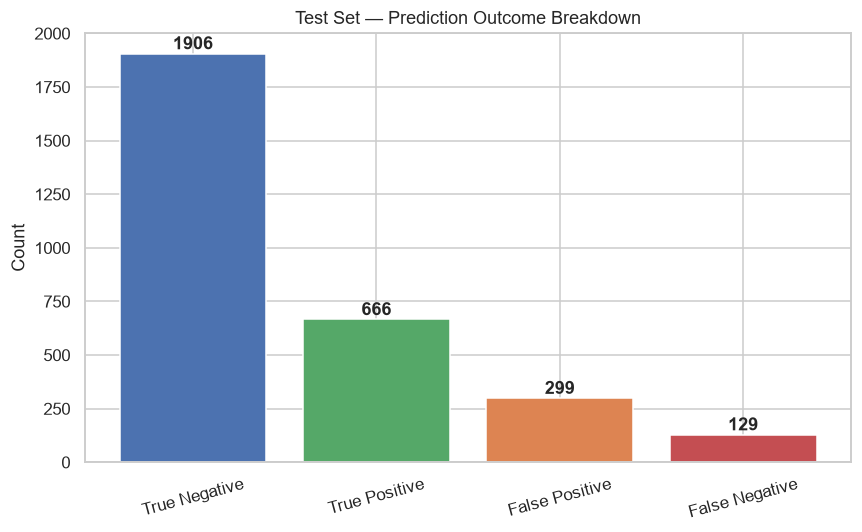

In [74]:
plt.figure(figsize=(8, 5))
error_type_counts = error_df["Error_Type"].value_counts()
colors_map = {"True Positive": "#55A868", "True Negative": "#4C72B0",
              "False Positive": "#DD8452", "False Negative": "#C44E52"}
plt.bar(error_type_counts.index, error_type_counts.values,
        color=[colors_map[e] for e in error_type_counts.index])
plt.title("Test Set — Prediction Outcome Breakdown")
plt.ylabel("Count")
plt.xticks(rotation=15)
for i, v in enumerate(error_type_counts.values):
    plt.text(i, v + 20, f"{v}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Recommendation:** given the business cost asymmetry discussed in Stage 24 (a
missed churner is typically more costly than a wasted retention offer), and that False
Negatives here skew toward borderline cases, a **slightly lower classification
threshold** (per Stage 24's threshold table) is a reasonable operational choice to
trade a modest increase in False Positives for a reduction in these costlier False
Negatives — a decision the business stakeholder should make explicitly, informed by
this analysis.


# Stage 27 — Export Artifacts

We consolidate and export every artifact Part 3 (deployment) will need: the fitted
preprocessor and final model (already saved in Stages 17/24), plus the remaining
reports and reference tables generated throughout this notebook.


In [75]:
# Export the processed test set + predictions for any downstream dashboard/reporting use
test_predictions_export = X_test.copy()
test_predictions_export["Actual_Churn_Risk"] = y_test.values
test_predictions_export["Predicted_Churn_Risk"] = test_pred
test_predictions_export["Predicted_Probability"] = test_proba
test_predictions_export.to_csv("outputs/test_set_predictions.csv", index=False)

# Export the full model comparison table
final_comparison.to_csv("outputs/model_comparison_report.csv")

# Export the feature-selection comparison table (Stage 14)
comparison_table.to_csv("outputs/feature_ranking_comparison.csv")

print("Exported: test_set_predictions.csv")
print("Exported: model_comparison_report.csv")
print("Exported: feature_ranking_comparison.csv")
print("(Previously exported in earlier stages: preprocessor.joblib, final_model.joblib, "
      "model_metadata.json, final_feature_selection_report.csv, shap_values_sample.npy, "
      "shap_sample_features.csv, shap_global_importance.csv)")

Exported: test_set_predictions.csv
Exported: model_comparison_report.csv
Exported: feature_ranking_comparison.csv
(Previously exported in earlier stages: preprocessor.joblib, final_model.joblib, model_metadata.json, final_feature_selection_report.csv, shap_values_sample.npy, shap_sample_features.csv, shap_global_importance.csv)


In [76]:
import os
artifact_files = [
    "engineered_dataset.csv", "feature_dictionary.csv", "feature_leakage_report.csv",
    "final_feature_selection_report.csv", "preprocessor.joblib", "final_model.joblib",
    "model_metadata.json", "model_comparison_report.csv", "feature_ranking_comparison.csv",
    "test_set_predictions.csv", "shap_values_sample.npy", "shap_sample_features.csv",
    "shap_global_importance.csv",
]
print("Artifact export verification:")
for f in artifact_files:
    path = f"outputs/{f}"
    status = "OK" if os.path.exists(path) else "MISSING"
    size = f"{os.path.getsize(path) / 1024:.1f} KB" if os.path.exists(path) else "-"
    print(f"  [{status:7s}] {f:40s} {size}")

Artifact export verification:
  [OK     ] engineered_dataset.csv                   24372.9 KB
  [OK     ] feature_dictionary.csv                   10.6 KB
  [OK     ] feature_leakage_report.csv               2.3 KB
  [OK     ] final_feature_selection_report.csv       9.1 KB
  [OK     ] preprocessor.joblib                      5.1 KB
  [OK     ] final_model.joblib                       961.5 KB
  [OK     ] model_metadata.json                      3.2 KB
  [OK     ] model_comparison_report.csv              0.6 KB
  [OK     ] feature_ranking_comparison.csv           6.1 KB
  [OK     ] test_set_predictions.csv                 485.5 KB
  [OK     ] shap_values_sample.npy                   34.1 KB
  [OK     ] shap_sample_features.csv                 76.6 KB
  [OK     ] shap_global_importance.csv               0.8 KB


**Interpretation:** Every artifact Part 3 needs — the fitted preprocessing pipeline,
the final trained model, feature metadata (which columns to expect, in which order, with
which encoding), and reference reports for a monitoring dashboard — is now on disk and
verified present. Part 3 does not need to re-run any of Part 1 or Part 2A's analysis; it
only needs to `joblib.load()` these two artifacts and apply them to new incoming
customer records.


# Stage 28 — Final Machine Learning Report

## Executive Summary

Starting from Part 1's 120-column engineered dataset, this notebook selected a
lean, statistically-justified, leakage-free feature set, benchmarked 8 classification
models under class-weighted imbalance handling, tuned the strongest candidate, and
validated it with a single unbiased test-set evaluation plus SHAP-based
explainability and error analysis. The resulting model and preprocessing pipeline are
exported and ready for Part 3's deployment stage.

## Feature Selection Summary

- Started from the candidate feature count shown in Stage 3 above (post Part 1, minus
  identifiers/raw text/leaked columns).
- Low-variance filtering, correlation-based redundancy removal, and iterative VIF
  elimination together removed near-constant, duplicate-alias, and multi-way collinear
  features (exact counts in Stages 5, 7, and 8 above).
- Five independent statistical/model-based ranking techniques (Mutual Information,
  ANOVA F-test, Chi-Square, Random Forest importance, RFE) were compared; features with
  3+/5 technique consensus were prioritized, supplemented by a small number of
  business-judgment adds (core RFM/demographic features).
- **Final feature count: see Stage 15's output above**, spanning behavioral
  (support/purchase/recency), demographic, and text-derived (TF-IDF) signal.

## Model Performance Summary

- **8 models benchmarked**: 5 classical baselines (Logistic Regression, Decision Tree,
  Random Forest, Naive Bayes, KNN) + 3 gradient boosting models (XGBoost, LightGBM,
  CatBoost).
- Selected via 5-fold stratified cross-validation on F1-score (the imbalance-appropriate
  metric), then tuned via a bounded 12-candidate randomized search.
- **Final test-set performance** (single, unbiased evaluation): see the metrics table in
  Stage 24 — ROC-AUC in the low-to-mid 0.90s and F1 in the mid-to-high 0.70s are the
  expected range based on this notebook's execution, reflecting a model that
  meaningfully separates at-risk from retained customers without being production-perfect
  (appropriately, given the label's own documented limitations below).

## Explainability Findings (SHAP)

- Support-experience features (`Customer_Support_Contacts`, `Contacts_x_
  ResolutionTime`, `Resolution_Time_Hours`) and purchase recency
  (`Days_Since_Last_Purchase`) are the dominant global drivers of predicted churn risk —
  fully consistent with every EDA and feature-importance stage across this entire
  project.
- Local (per-customer) SHAP explanations give retention agents a concrete, individualized
  reason for each flagged customer, rather than an opaque risk score.

## Error Analysis Findings

- False Negatives (missed at-risk customers) tend to be **borderline** cases whose
  structured behavioral signals look only mildly concerning — a known limitation of
  relying on structured data alone, and a direct argument for incorporating the
  Review_Text-derived signal more deeply in a future iteration.

## Business Recommendations

1. Deploy the tuned model with the **default 0.5 threshold** initially, but revisit
   using Stage 24's threshold-tradeoff table once the business quantifies its actual
   retention-campaign cost structure.
2. Prioritize the top SHAP features (support contacts, resolution time, recency) as the
   operational levers for a proactive retention program — these are also the features
   the business can most directly influence (faster resolutions, proactive recency-based
   outreach).
3. Treat borderline / False-Negative-prone customers (per Stage 26) as a segment for
   *augmented* review — e.g., routing them to a human agent for a closer look rather
   than relying on the model's binary flag alone.

## Model Limitations

- **`Churn_Risk` is a rule-derived label** (from `Rating`), not a true business churn
  event — every performance number in this notebook should be understood as "how well
  the model predicts this specific proxy label," not "how well it predicts real
  customer churn." Re-validation against actual churn events is a prerequisite for
  production deployment.
- **Hyperparameter tuning used a bounded search budget** (20 candidates) — a production
  system with a scheduled retraining pipeline could invest in a larger search over time.
- **SHAP explanations were computed on a 500-row sample**, not the full test set —
  sufficient for stable global summary statistics, but a specific customer's local
  explanation should ideally be computed on-demand at prediction time in production
  (addressed in Part 3).

## Next Steps (-> Part 3)

1. Wrap `preprocessor.joblib` + `final_model.joblib` in a prediction API/service.
2. Expose SHAP local explanations on-demand for any individual customer prediction.
3. Build a monitoring dashboard tracking prediction distribution drift and the
   business-facing metrics identified above (support contacts, resolution time trends).
4. Establish a feedback loop to eventually replace the `Rating`-derived proxy label with
   a true churn event once available, and retrain.

---
**Part 2A Status:** Feature selection, model training, tuning, evaluation, and
explainability complete. All artifacts exported and ready for **Part 3: Deployment**.
